# 02. Classical Models

This notebook establishes classical point-forecast baselines for the Kaggle *Hedge Fund — Time Series Forecasting* panel. It honors the EDA findings: §11 showed that 100% of eligible series become stationary after first differencing, so every parametric model here either fits on first differences (AR, MA, ARMA) or uses `d=1` inside the ARIMA/SARIMA machinery.

## 0. Setup

Imports, constants, data load, and the shared metric functions every later cell uses.

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110

# --- paths and constants ---
PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data' / 'ts-forecasting'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VAL_CUTOFF = 2880
SEED = 42

# For quick iteration, set SAMPLE_SIZE to a small int (e.g. 200).
# Set to None for the full eligible universe (~1930 series).
SAMPLE_SIZE = 200

train = pd.read_parquet(
    DATA_DIR / 'train.parquet',
    columns=['code', 'sub_code', 'sub_category', 'horizon', 'ts_index', 'y_target', 'weight'],
)
series_keys = ['code', 'sub_code', 'sub_category', 'horizon']

print(f'Train rows: {len(train):,}')
print(f'VAL_CUTOFF: {VAL_CUTOFF}')
print(f'SAMPLE_SIZE: {SAMPLE_SIZE}')

Train rows: 5,337,414
VAL_CUTOFF: 2880
SAMPLE_SIZE: 200


### 0.1 Metric functions

We score every (series, model) pair with four losses:

- **Weighted Skill Score** — the competition metric: `sqrt(1 - clip01(Σw·(y-ŷ)² / Σw·y²))`.
- **Weighted RMSE** — raw-scale error.
- **Weighted MAE** — robust error.
- **MASE** — mean absolute error scaled by the naive one-step error on training. Scale-independent → comparable across series with very different target magnitudes.

In [2]:
def weighted_skill(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight * (y_true ** 2))
    if denom == 0:
        return np.nan
    ratio = np.sum(weight * ((y_true - y_pred) ** 2)) / denom
    ratio = min(max(ratio, 0.0), 1.0)
    return float(np.sqrt(1.0 - ratio))

def weighted_rmse(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    if np.sum(weight) == 0:
        return np.nan
    return float(np.sqrt(np.sum(weight * ((y_true - y_pred) ** 2)) / np.sum(weight)))

def weighted_mae(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    if np.sum(weight) == 0:
        return np.nan
    return float(np.sum(weight * np.abs(y_true - y_pred)) / np.sum(weight))

def mase(y_true, y_pred, train_scale):
    if not np.isfinite(train_scale) or train_scale == 0:
        return np.nan
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)) / train_scale)

### 0.2 Series utilities

Helpers for extracting a single series from the panel and splitting it at `VAL_CUTOFF`.

In [3]:
def get_series_df(meta_row):
    mask = (
        (train['code'] == meta_row.code)
        & (train['sub_code'] == meta_row.sub_code)
        & (train['sub_category'] == meta_row.sub_category)
        & (train['horizon'] == meta_row.horizon)
    )
    return train.loc[mask, ['ts_index', 'y_target', 'weight']].sort_values('ts_index').reset_index(drop=True)

def split_series(series_df):
    train_part = series_df[series_df['ts_index'] <= VAL_CUTOFF].copy()
    val_part = series_df[series_df['ts_index'] > VAL_CUTOFF].copy()
    return train_part, val_part

## 1. Why this notebook exists

Classical models are not expected to win overall — global ML models will see the 86 anonymized features and cross-series structure that univariate methods cannot. So why run them?

1. **Establish a defensible floor.** If ML can't beat Naive, something is broken.
2. **Map where univariate structure lives.** The per-horizon and per-sub-category breakdowns tell us which parts of the panel have real serial structure vs noise.
3. **Feed the ensemble notebook.** `05_ensemble_hybrid.ipynb` uses per-series winners as one of its selection strategies. We produce that table here.
4. **Honor the EDA.** §11 of `01_EDA_claude.ipynb` showed 100% stationarity after first differencing. That's a load-bearing claim, and this notebook tests it by reporting d=0 vs d=1 ARIMA head-to-head in §8.

## 2. What the EDA told us — constraints this notebook must honor

Hard constraints pulled from `01_EDA_claude.ipynb`:

| EDA finding | Section | Consequence here |
|---|---|---|
| Target is heavy-tailed, median ≈ 0 | §4 | Include **Zero** as a baseline — the skill-score denominator is the zero-forecast error. |
| Weights concentrate ~65% in top 1% of rows | §5 | **Never report unweighted metrics as primary.** All leaderboards use weighted skill / RMSE / MAE. |
| Only ~1930 series cross `VAL_CUTOFF = 2880` | §6 | Evaluate only eligible series — same filter as EDA. |
| Weak per-feature correlations (|ρ| < 0.10) | §7 | Classical univariate methods can't exploit features, but that's fine; this is the univariate baseline run. |
| **100% of eligible series stationary after first differencing** | §11 | **Every parametric model uses first differencing** — either explicitly (AR/MA/ARMA fit on `diff(y)`) or implicitly via `d=1` in ARIMA/SARIMA. |
| Top panel-level ACF lags are short (1, 2, 3) | §14 | AR and MA orders focus on p, q ∈ {1, 2, 3}. |
| No panel-wide seasonality | §14, §15 | SARIMA included for completeness, not because we expect wins. |

The single most consequential finding is the stationarity result. That's what shapes the model lineup below.

## 3. Model lineup

Grouped into six families. Non-baseline families all use first differencing — see the notes under each group.

### 3A. Baselines (on levels)

No fitting, no differencing. These measure how much of the scored metric is explainable by trivial rules — any real model has to beat them to justify its complexity.

**Zero** — `ŷ_{t+h} = 0` for every step.
The skill-score denominator is `Σw·y²`, which is exactly the squared error of a zero forecast. So a skill score of 0 literally means "no better than predicting zero." Including Zero as a model makes the metric's geometry visible in the leaderboard.

**Naive** — `ŷ_{t+h} = y_t`.
"Tomorrow looks like today." Wins when the series is dominated by slow drift with short-horizon persistence (large lag-1 autocorrelation). Loses whenever there is mean reversion or the last point is an outlier.

**Drift** — `ŷ_{t+h} = y_t + h · slope`, slope = `(y_t − y_1) / (n − 1)`.
Straight-line extrapolation through the first and last training observations. Wins on monotone-trending series. Dangerous when the *start* or *end* of the training window is an outlier — the slope can point anywhere.

**Expanding Mean** — `ŷ_{t+h} = (1/t) Σ y_i`.
"Long-run average." Wins on mean-reverting series with no trend. Loses whenever there is any drift.

**Rolling Mean (w=10)** — `ŷ_{t+h} = mean(last 10 observations)`.
Local mean. Smoother than Naive, more reactive than Expanding Mean. Window size is a tunable knob; we fix it at 10 for this notebook.

In [4]:
# --- baseline forecasts (operate on the original level series) ---

def forecast_zero(y, steps):
    return np.zeros(steps)

def forecast_naive(y, steps):
    return np.repeat(float(y.iloc[-1]), steps)

def forecast_drift(y, steps):
    if len(y) < 2:
        raise ValueError('drift needs >= 2 observations')
    slope = (float(y.iloc[-1]) - float(y.iloc[0])) / (len(y) - 1)
    return float(y.iloc[-1]) + slope * np.arange(1, steps + 1)

def forecast_expanding_mean(y, steps):
    return np.repeat(float(y.mean()), steps)

def forecast_rolling_mean(y, steps, window=10):
    w = min(window, len(y))
    return np.repeat(float(y.iloc[-w:].mean()), steps)

### 3B. AR family — fit on first differences

**Model.** An AR(p) model writes today's value as a linear combination of the previous p values plus noise:

$$ y_t \;=\; c \;+\; \phi_1\, y_{t-1} \;+\; \phi_2\, y_{t-2} \;+\; \cdots \;+\; \phi_p\, y_{t-p} \;+\; \varepsilon_t $$

On *differenced* data, the same model reads: $\Delta y_t = c + \phi_1 \Delta y_{t-1} + \cdots + \phi_p \Delta y_{t-p} + \varepsilon_t$. This is implemented as `ARIMA(p, 1, 0)` — the `d=1` tells statsmodels to difference internally, fit AR(p) to the result, and re-integrate the forecast back to level space.

**Why differences, not levels?** EDA §11 showed that 100% of eligible series become stationary after one differencing. Fitting AR on non-stationary levels produces spurious coefficients and divergent forecasts. `d=1` is **identical across every AR variant** below.

**Intuition.** p is the memory depth. AR(1) says "only yesterday matters." AR(10) says "the last ten days jointly matter, each with its own weight."

**Strengths.** Cheap, interpretable, optimal when the true DGP is linear in its own past.

**Weaknesses.** Cannot model nonlinearity (regime changes, volatility clustering). Higher p fits more parameters → overfitting risk on short series (which is why `min_train` scales with p).

**Lineup (p = 1..10, all on first differences):**

| Label | Equivalent ARIMA order |
|---|---|
| AR(1)  | (1, 1, 0) |
| AR(2)  | (2, 1, 0) |
| AR(3)  | (3, 1, 0) |
| AR(4)  | (4, 1, 0) |
| AR(5)  | (5, 1, 0) |
| AR(6)  | (6, 1, 0) |
| AR(7)  | (7, 1, 0) |
| AR(8)  | (8, 1, 0) |
| AR(9)  | (9, 1, 0) |
| AR(10) | (10, 1, 0) |

Having p = 1..10 lets §6b plot loss-vs-lag curves, so we can see where returns saturate rather than guessing.

### 3C. MA family — fit on first differences

**Concept.** An MA(q) model says today's differenced value is a linear combination of the last q *innovations* (random shocks), not the last q values:

`Δy_t = c + ε_t + θ₁ ε_{t-1} + θ₂ ε_{t-2} + … + θ_q ε_{t-q}`

Where AR lets past values drive today, MA lets past *surprises* drive today. MA(1) on differences is famous — it's exactly Simple Exponential Smoothing in disguise. Implementation: `ARIMA(0, 1, q)`.

| Label | Equivalent ARIMA order |
|---|---|
| MA(1)  | (0, 1, 1) |
| MA(2)  | (0, 1, 2) |
| MA(3)  | (0, 1, 3) |
| MA(4)  | (0, 1, 4) |
| MA(5)  | (0, 1, 5) |
| MA(6)  | (0, 1, 6) |
| MA(7)  | (0, 1, 7) |
| MA(8)  | (0, 1, 8) |
| MA(9)  | (0, 1, 9) |
| MA(10) | (0, 1, 10) |

Ten MA variants mirror the AR lineup, so §6e can plot loss-vs-lag for MA on the same x-axis as §6b's AR scan.

### 3D. ARMA family — fit on first differences

**Concept.** ARMA combines both channels — past values AND past shocks:

`Δy_t = c + Σᵢ φᵢ Δy_{t-i} + Σⱼ θⱼ ε_{t-j} + ε_t`

Ten ARMA variants cover a range of `(p, q)` combinations so §6f can scan loss versus total order `p + q`. Implementation: `ARIMA(p, 1, q)` with both p ≥ 1 and q ≥ 1.

| Label | Equivalent ARIMA order | Total order (p + q) |
|---|---|---|
| ARMA(1,1) | (1, 1, 1) | 2 |
| ARMA(2,1) | (2, 1, 1) | 3 |
| ARMA(1,2) | (1, 1, 2) | 3 |
| ARMA(2,2) | (2, 1, 2) | 4 |
| ARMA(3,1) | (3, 1, 1) | 4 |
| ARMA(1,3) | (1, 1, 3) | 4 |
| ARMA(3,2) | (3, 1, 2) | 5 |
| ARMA(2,3) | (2, 1, 3) | 5 |
| ARMA(3,3) | (3, 1, 3) | 6 |
| ARMA(4,4) | (4, 1, 4) | 8 |

### 3E. ARIMA family — explicit d comparison

**Model.** ARIMA(p, d, q) is "ARMA(p, q) applied to y after differencing d times." The `I` stands for **integrated** — if d = 1, the model assumes `diff(y)` is stationary; if d = 2, it assumes `diff(diff(y))` is stationary; etc.

**Why include d = 0 and d = 1 variants both?** §8 runs a matched-pair head-to-head: if EDA §11's stationarity claim is load-bearing, d = 1 should win most series. We include ARIMA(1, 0, 0), ARIMA(1, 0, 1), ARIMA(2, 0, 2) explicitly so the scatter has matched-order pairs to compare against AR(1), ARMA(1,1), ARMA(2,2) on first differences.

**Lineup:**

| Label | Note |
|---|---|
| ARIMA(0,1,0) | pure random walk — the "nothing fits, just predict last value with drift" baseline |
| ARIMA(1,0,0) | AR(1) on **levels** — d=0 contrast for §8 |
| ARIMA(1,0,1) | ARMA(1,1) on **levels** — d=0 contrast |
| ARIMA(2,0,2) | ARMA(2,2) on **levels** — d=0 contrast |

### 3F. SARIMA — for completeness

**Model.** SARIMA(p, d, q)(P, D, Q, s) adds a second, seasonal block of AR, differencing, and MA terms with period s:

$$ \Phi(B^s)\, \phi(B)\, (1 - B)^d\, (1 - B^s)^D\, y_t \;=\; \Theta(B^s)\, \theta(B)\, \varepsilon_t $$

Period s = 7 captures weekly-like cycles; s = 24 captures daily-length cycles in hourly data.

**Why include despite no panel-wide seasonality?** EDA §14 showed flat panel-level ACF at seasonal lags and §15's STL did not reveal dominant periods — so we *don't* expect SARIMA to win broadly. But §13 case studies might surface a slice of series where local seasonality is real, and SARIMA gives us a way to detect that.

**Weakness at scale.** Seasonal models need many observations (`min_train` = 50 or 80 in the lineup below) because they estimate 2× the parameters of non-seasonal ARIMA. Expect high skip rates on short series in §11.

**Lineup:**

| Label | Note |
|---|---|
| SARIMA(1,1,1)(1,1,1,7)  | weekly-length cycle |
| SARIMA(1,1,1)(1,1,1,24) | daily-length cycle |

In [5]:
# --- parametric forecasts (ARIMA and SARIMA, d handled by the library) ---

def make_arima_forecaster(order):
    def _f(y, steps):
        fit = ARIMA(y, order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False).fit()
        pred = np.asarray(fit.forecast(steps), dtype=float)
        if not np.all(np.isfinite(pred)):
            raise ValueError('non-finite forecast')
        return pred
    return _f

def make_sarima_forecaster(order, seasonal_order):
    def _f(y, steps):
        fit = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                      enforce_stationarity=False,
                      enforce_invertibility=False).fit(disp=False)
        pred = np.asarray(fit.forecast(steps), dtype=float)
        if not np.all(np.isfinite(pred)):
            raise ValueError('non-finite forecast')
        return pred
    return _f

### 3G. MODEL_SPECS — the full lineup

Every (series, model) pair in the full rerun uses this dict. `min_train` is the skip gate: if a series has fewer training observations than the gate, the row is recorded with `status='skipped'` — visible in §11.

In [6]:
MODEL_SPECS = {
    # --- 3A. Baselines (on levels) ---
    'Zero':                 {'min_train': 1,  'func': forecast_zero},
    'Naive':                {'min_train': 1,  'func': forecast_naive},
    'Drift':                {'min_train': 2,  'func': forecast_drift},
    'Expanding Mean':       {'min_train': 1,  'func': forecast_expanding_mean},
    'Rolling Mean (w=10)':  {'min_train': 2,  'func': lambda y, s: forecast_rolling_mean(y, s, 10)},

    # --- 3B. AR family on first differences: ARIMA(p, 1, 0), p = 1..10 ---
    'AR(1)':  {'min_train': 25, 'func': make_arima_forecaster((1,  1, 0))},
    'AR(2)':  {'min_train': 25, 'func': make_arima_forecaster((2,  1, 0))},
    'AR(3)':  {'min_train': 25, 'func': make_arima_forecaster((3,  1, 0))},
    'AR(4)':  {'min_train': 28, 'func': make_arima_forecaster((4,  1, 0))},
    'AR(5)':  {'min_train': 30, 'func': make_arima_forecaster((5,  1, 0))},
    'AR(6)':  {'min_train': 32, 'func': make_arima_forecaster((6,  1, 0))},
    'AR(7)':  {'min_train': 34, 'func': make_arima_forecaster((7,  1, 0))},
    'AR(8)':  {'min_train': 36, 'func': make_arima_forecaster((8,  1, 0))},
    'AR(9)':  {'min_train': 38, 'func': make_arima_forecaster((9,  1, 0))},
    'AR(10)': {'min_train': 40, 'func': make_arima_forecaster((10, 1, 0))},

    # --- 3C. MA family on first differences: ARIMA(0, 1, q), q = 1..10 ---
    'MA(1)':  {'min_train': 25, 'func': make_arima_forecaster((0, 1, 1))},
    'MA(2)':  {'min_train': 25, 'func': make_arima_forecaster((0, 1, 2))},
    'MA(3)':  {'min_train': 25, 'func': make_arima_forecaster((0, 1, 3))},
    'MA(4)':  {'min_train': 28, 'func': make_arima_forecaster((0, 1, 4))},
    'MA(5)':  {'min_train': 30, 'func': make_arima_forecaster((0, 1, 5))},
    'MA(6)':  {'min_train': 32, 'func': make_arima_forecaster((0, 1, 6))},
    'MA(7)':  {'min_train': 34, 'func': make_arima_forecaster((0, 1, 7))},
    'MA(8)':  {'min_train': 36, 'func': make_arima_forecaster((0, 1, 8))},
    'MA(9)':  {'min_train': 38, 'func': make_arima_forecaster((0, 1, 9))},
    'MA(10)': {'min_train': 40, 'func': make_arima_forecaster((0, 1, 10))},

    # --- 3D. ARMA family on first differences: ARIMA(p, 1, q), 10 variants ---
    'ARMA(1,1)': {'min_train': 30, 'func': make_arima_forecaster((1, 1, 1))},
    'ARMA(2,1)': {'min_train': 30, 'func': make_arima_forecaster((2, 1, 1))},
    'ARMA(1,2)': {'min_train': 30, 'func': make_arima_forecaster((1, 1, 2))},
    'ARMA(2,2)': {'min_train': 35, 'func': make_arima_forecaster((2, 1, 2))},
    'ARMA(3,1)': {'min_train': 35, 'func': make_arima_forecaster((3, 1, 1))},
    'ARMA(1,3)': {'min_train': 35, 'func': make_arima_forecaster((1, 1, 3))},
    'ARMA(3,2)': {'min_train': 38, 'func': make_arima_forecaster((3, 1, 2))},
    'ARMA(2,3)': {'min_train': 38, 'func': make_arima_forecaster((2, 1, 3))},
    'ARMA(3,3)': {'min_train': 40, 'func': make_arima_forecaster((3, 1, 3))},
    'ARMA(4,4)': {'min_train': 45, 'func': make_arima_forecaster((4, 1, 4))},

    # --- 3E. ARIMA — explicit d for §8 head-to-head ---
    'ARIMA(0,1,0)':         {'min_train': 25, 'func': make_arima_forecaster((0, 1, 0))},
    'ARIMA(1,0,0)':         {'min_train': 25, 'func': make_arima_forecaster((1, 0, 0))},
    'ARIMA(1,0,1)':         {'min_train': 25, 'func': make_arima_forecaster((1, 0, 1))},
    'ARIMA(2,0,2)':         {'min_train': 30, 'func': make_arima_forecaster((2, 0, 2))},

    # --- 3F. SARIMA ---
    'SARIMA(1,1,1)(1,1,1,7)':  {'min_train': 50, 'func': make_sarima_forecaster((1,1,1), (1,1,1,7))},
    'SARIMA(1,1,1)(1,1,1,24)': {'min_train': 80, 'func': make_sarima_forecaster((1,1,1), (1,1,1,24))},
}

print(f'Total models: {len(MODEL_SPECS)}')
print('Families:')
print(f'  Baselines:  5')
print(f'  AR:         10')
print(f'  MA:         10')
print(f'  ARMA:       10')
print(f'  ARIMA(d in {{0,1}}): 4')
print(f'  SARIMA:     2')

Total models: 41
Families:
  Baselines:  5
  AR:         10
  MA:         10
  ARMA:       10
  ARIMA(d in {0,1}): 4
  SARIMA:     2


## 4. Evaluation design

**Eligibility.** A series is eligible iff it crosses `VAL_CUTOFF = 2880` — same rule used in EDA §6. That leaves ~1930 series.

**Temporal split.** `train = ts_index ≤ 2880`, `validation = ts_index > 2880`. No random CV.

**Level-space scoring.** The competition scores predictions of `y_target` (the level). All our forecast functions return level-space forecasts — ARIMA/SARIMA re-integrate internally when `d≥1`, and baselines were always on levels.

**Sampling.** For quick iteration, `SAMPLE_SIZE` restricts the eligible universe. Set it to `None` for the full run.

In [7]:
series_meta = (
    train.groupby(series_keys)['ts_index']
         .agg(first='min', last='max', length='count')
         .reset_index()
)
series_meta['crosses_cutoff'] = (series_meta['first'] <= VAL_CUTOFF) & (series_meta['last'] > VAL_CUTOFF)
eligible_meta = series_meta[series_meta['crosses_cutoff']].copy().reset_index(drop=True)

print(f'Total series:    {len(series_meta):,}')
print(f'Eligible series: {len(eligible_meta):,}')
print(f'Sample size for this run: {SAMPLE_SIZE if SAMPLE_SIZE else len(eligible_meta)}')

Total series:    36,923
Eligible series: 1,930
Sample size for this run: 200


## 5. Full rerun

For each (series, model) pair we record:

- `status` ∈ {`ok`, `skipped`, `failed`} and a reason when not ok.
- When ok: `skill_score`, `rmse`, `mae`, `mase`.

Skips happen when `train_len < min_train`; failures happen when a model's fit raises or produces non-finite values.

In [8]:
rng = np.random.default_rng(SEED)
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(eligible_meta):
    sampled_meta = eligible_meta.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
else:
    sampled_meta = eligible_meta.copy()

results_rows = []
total = len(sampled_meta)

for idx, meta_row in enumerate(sampled_meta.itertuples(index=False), start=1):
    series_df = get_series_df(meta_row)
    train_part, val_part = split_series(series_df)
    y_train = train_part['y_target'].reset_index(drop=True)
    y_val = val_part['y_target'].to_numpy(dtype=float)
    w_val = val_part['weight'].to_numpy(dtype=float)
    steps = len(val_part)

    # MASE denominator: mean absolute one-step change on training
    train_scale = float(np.mean(np.abs(np.diff(y_train)))) if len(y_train) > 1 else np.nan

    series_name = f"{meta_row.code}_{meta_row.sub_code}_H{meta_row.horizon}"

    for model_name, spec in MODEL_SPECS.items():
        row = {
            'series': series_name,
            'code': meta_row.code,
            'sub_code': meta_row.sub_code,
            'sub_category': meta_row.sub_category,
            'horizon': int(meta_row.horizon),
            'train_len': int(len(y_train)),
            'val_len': int(steps),
            'model': model_name,
            'status': 'ok',
            'skip_reason': None,
            'skill_score': np.nan, 'rmse': np.nan, 'mae': np.nan, 'mase': np.nan,
        }
        if len(y_train) < spec['min_train']:
            row['status'] = 'skipped'
            row['skip_reason'] = f"train_len<{spec['min_train']}"
            results_rows.append(row)
            continue
        try:
            pred = spec['func'](y_train, steps)
            pred = np.asarray(pred, dtype=float)
            row['skill_score'] = weighted_skill(y_val, pred, w_val)
            row['rmse']        = weighted_rmse(y_val, pred, w_val)
            row['mae']         = weighted_mae(y_val, pred, w_val)
            row['mase']        = mase(y_val, pred, train_scale)
        except Exception as e:
            row['status'] = 'failed'
            row['skip_reason'] = type(e).__name__
        results_rows.append(row)

    if idx % 25 == 0 or idx == total:
        print(f'  processed {idx}/{total} series')

results = pd.DataFrame(results_rows)
print(f'\nTotal rows: {len(results):,}')
print(f'Status counts:')
print(results['status'].value_counts())
results.head()

  processed 25/200 series
  processed 50/200 series
  processed 75/200 series
  processed 100/200 series
  processed 125/200 series
  processed 150/200 series
  processed 175/200 series
  processed 200/200 series

Total rows: 8,200
Status counts:
status
ok         6735
skipped    1464
failed        1
Name: count, dtype: int64


,series,code,sub_code,sub_category,horizon,train_len,val_len,model,status,skip_reason,skill_score,rmse,mae,mase
0,MRV5UON2_KL66VIS3_H10,MRV5UON2,KL66VIS3,V8BKY1IV,10,107,40,Zero,ok,NaN,0.0,0.040570,0.025502,2.176328
1,MRV5UON2_KL66VIS3_H10,MRV5UON2,KL66VIS3,V8BKY1IV,10,107,40,Naive,ok,NaN,0.0,0.045132,0.034067,2.930023
2,MRV5UON2_KL66VIS3_H10,MRV5UON2,KL66VIS3,V8BKY1IV,10,107,40,Drift,ok,NaN,0.0,0.049869,0.041359,3.556922
3,MRV5UON2_KL66VIS3_H10,MRV5UON2,KL66VIS3,V8BKY1IV,10,107,40,Expanding Mean,ok,NaN,0.0,0.040716,0.025055,2.147520
4,MRV5UON2_KL66VIS3_H10,MRV5UON2,KL66VIS3,V8BKY1IV,10,107,40,Rolling Mean (w=10),ok,NaN,0.0,0.041229,0.027135,2.316780


## 6. Leaderboard

Per-model summary with mean, median, IQR, positive-skill hit rate, and coverage. A boxplot at the end makes the spread obvious.

In [9]:
ok = results[results['status'] == 'ok'].copy()

leaderboard = (
    ok.groupby('model')
      .agg(
          n_ok=('series', 'count'),
          mean_skill=('skill_score', 'mean'),
          median_skill=('skill_score', 'median'),
          q25=('skill_score', lambda s: s.quantile(0.25)),
          q75=('skill_score', lambda s: s.quantile(0.75)),
          positive_rate=('skill_score', lambda s: float((s > 0).mean())),
          mean_rmse=('rmse', 'mean'),
          mean_mae=('mae', 'mean'),
          mean_mase=('mase', 'mean'),
      )
      .sort_values('mean_skill', ascending=False)
)
leaderboard.round(4)

,n_ok,mean_skill,median_skill,q25,q75,positive_rate,mean_rmse,mean_mae,mean_mase
model,,,,,,,,,
MA(10),147,0.1235,0.0,0.0,0.1208,0.3333,2.703816e+07,2.698599e+07,1.653639e+08
"ARIMA(1,0,0)",171,0.1214,0.0,0.0,0.1355,0.3626,6.290100e+00,5.095700e+00,1.566220e+01
MA(7),161,0.1176,0.0,0.0,0.1324,0.3292,5.274400e+00,4.215200e+00,3.251700e+00
"ARIMA(1,0,1)",171,0.1154,0.0,0.0,0.1327,0.3333,8.122200e+00,5.986000e+00,5.381529e+02
MA(8),155,0.1151,0.0,0.0,0.1631,0.3290,5.652500e+00,4.575600e+00,3.243200e+00
"ARMA(4,4)",143,0.1145,0.0,0.0,0.1424,0.3147,9.263991e+02,2.921566e+02,1.433367e+05
"ARIMA(2,0,2)",166,0.1100,0.0,0.0,0.1307,0.3133,1.308952e+47,1.758873e+46,5.130445e+48
MA(9),147,0.1085,0.0,0.0,0.1098,0.3197,6.121300e+00,4.976200e+00,3.103700e+00
AR(10),147,0.1046,0.0,0.0,0.0461,0.2721,6.615600e+00,5.490600e+00,1.414780e+01


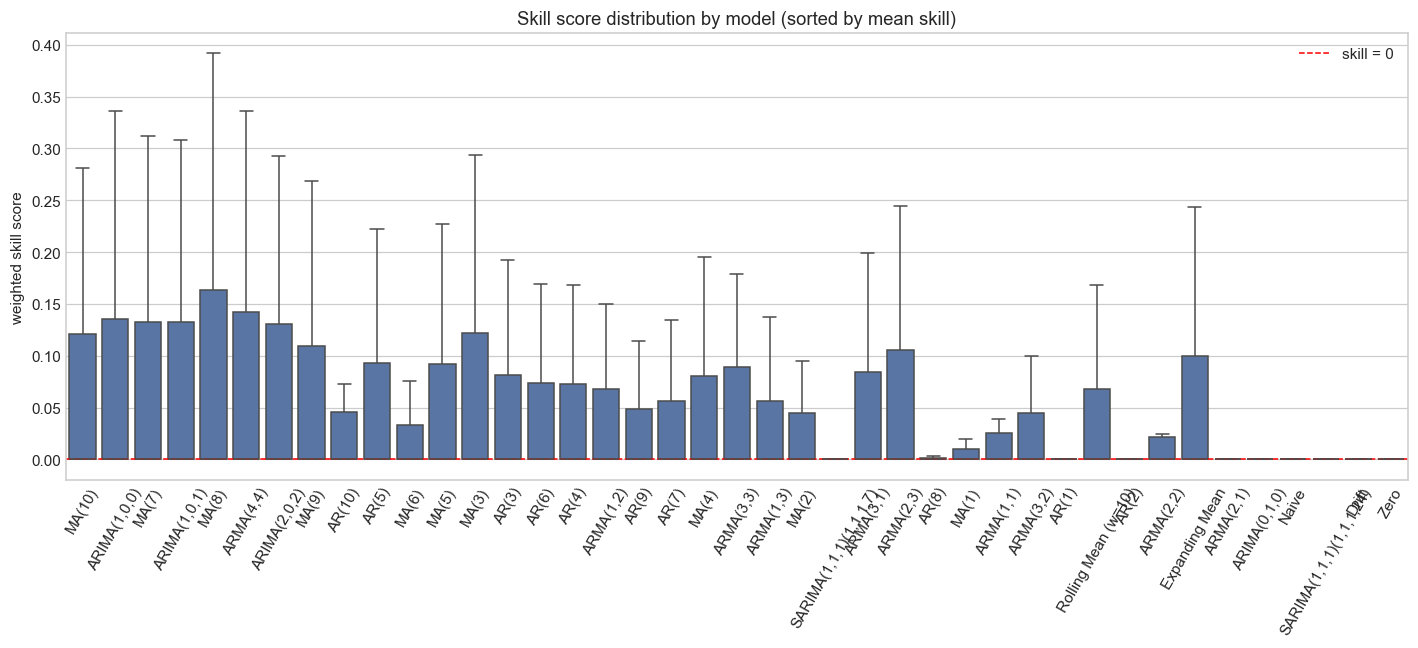

In [10]:
# boxplot of skill score per model, sorted by median skill
order = leaderboard.index.tolist()
fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=ok, x='model', y='skill_score', order=order,
            showfliers=False, color='#4C72B0', ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='skill = 0')
ax.set_title('Skill score distribution by model (sorted by mean skill)')
ax.set_xlabel('')
ax.set_ylabel('weighted skill score')
ax.tick_params(axis='x', rotation=60)
ax.legend()
plt.tight_layout()
plt.show()

**Reading.** Mean skill alone is misleading — a model with a big spread and a thin right tail can look strong. The boxplot surfaces which models are consistent (tight IQR around positive values) vs erratic (wide IQR, lots of zeros). The red dashed line marks skill = 0: models whose IQR sits on or below it are effectively at parity with predicting zero.

## 6b. Loss vs lag — AR family scan

A natural question after the leaderboard: does adding more AR lags keep improving the fit, or does it saturate / overfit? We plot the mean of each loss against the AR order p for p = 1..10. The skill panel should climb then plateau; the error panels (RMSE, MAE, MASE) should fall then plateau. A climb followed by a downturn would indicate overfitting (more parameters, worse out-of-sample).

All ten AR variants use the same `(p, 1, 0)` ARIMA order — same first-differencing, only `p` changes. That's exactly the one-dimensional sweep that lets us read the loss curves as a function of lag order alone.

In [11]:
ar_models = [f'AR({p})' for p in range(1, 11)]

ar_scan = (
    ok[ok['model'].isin(ar_models)]
      .groupby('model')
      .agg(mean_skill=('skill_score', 'mean'),
           mean_rmse =('rmse',        'mean'),
           mean_mae  =('mae',         'mean'),
           mean_mase =('mase',        'mean'),
           n_ok      =('series',      'count'))
      .reindex(ar_models)
)
ar_scan.index = [int(m[3:-1]) for m in ar_scan.index]
ar_scan.index.name = 'p'
ar_scan

,mean_skill,mean_rmse,mean_mae,mean_mase,n_ok
p,,,,,
1,0.087249,7.417516,6.203663,3.579276,171
2,0.086438,7.325360,6.109144,3.529986,171
3,0.101953,7.138199,5.906221,3.466372,171
4,0.100318,7.347003,6.084499,3.510168,167
5,0.103949,7.453106,6.174821,5.053092,166
6,0.100755,7.343783,6.051422,12.633958,166
7,0.098932,6.048973,4.940287,25.221296,161
8,0.091165,77.532289,33.448568,32652.578218,155
9,0.099101,6.517063,5.350071,8.955916,147


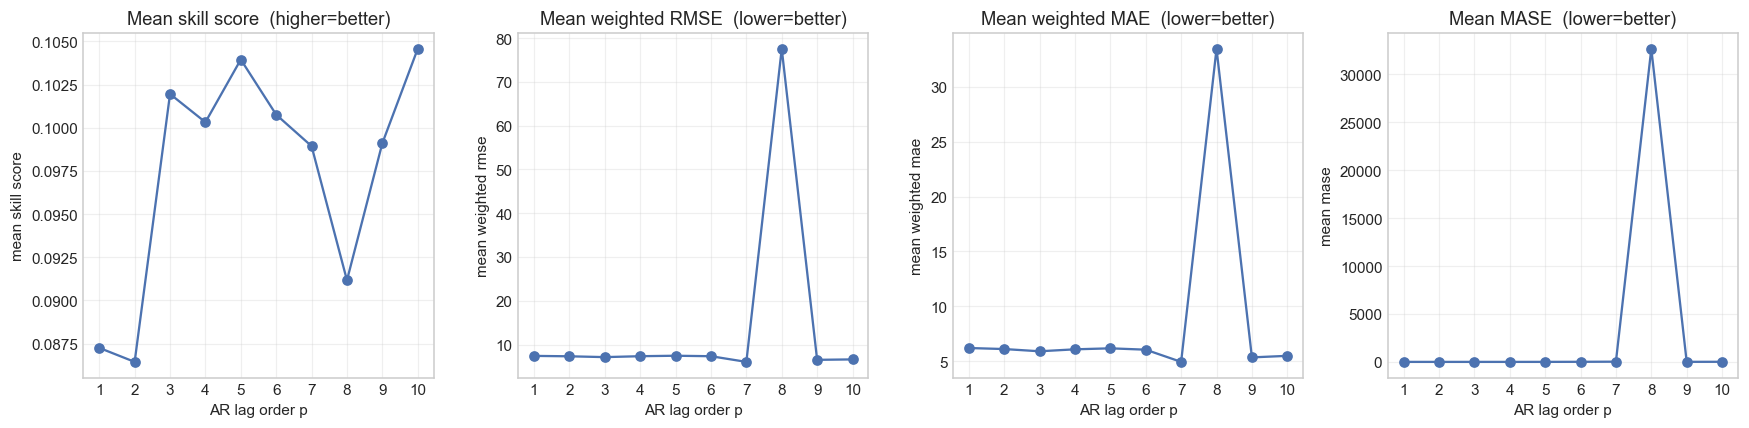

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col, title, higher_better in zip(
    axes,
    ['mean_skill', 'mean_rmse', 'mean_mae', 'mean_mase'],
    ['Mean skill score', 'Mean weighted RMSE', 'Mean weighted MAE', 'Mean MASE'],
    [True, False, False, False],
):
    ax.plot(ar_scan.index, ar_scan[col], marker='o', color='#4C72B0')
    direction = 'higher=better' if higher_better else 'lower=better'
    ax.set_title(f'{title}  ({direction})')
    ax.set_xlabel('AR lag order p')
    ax.set_ylabel(title.lower())
    ax.set_xticks(ar_scan.index)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Reading.** Look for three shapes:

- **Monotone improvement** — each added lag helps. Unlikely on noisy financial-like data.
- **Plateau after a small p** — marginal value of lags 4+ is zero. The "right" AR order is near the plateau start.
- **Climb then regression** — overfitting. More parameters hurt out-of-sample skill. Pick the smallest p at the peak.

Cross-reference with EDA §14's panel mean |PACF| plot — the lags that looked significant there should also be the ones that show up before the plateau here. Agreement between the two diagnostics is a green flag; disagreement is worth understanding.

## 6c. Per-series AR lag sweep

§6b averaged loss across all series. An average can hide series-level variation — some series might saturate at AR(2), others might keep improving up to AR(10). Here we pick four representative series and plot the skill curve for each individually.

The "right" AR order for the panel is the smallest p at which most per-series curves plateau.

In [13]:
# Pick 4 representative series where every AR(p) succeeded (ok status for all 10).
ar_names = [f'AR({p})' for p in range(1, 11)]
counts = (ok[ok['model'].isin(ar_names)]
              .groupby('series').size())
full_ar_series = counts[counts == 10].index.tolist()

# Diversify picks: spread them across train_len quartiles so we see short / medium / long series.
sub_full = ok[ok['series'].isin(full_ar_series) & (ok['model'] == 'AR(1)')][['series', 'train_len']].drop_duplicates()
sub_full = sub_full.sort_values('train_len').reset_index(drop=True)
if len(sub_full) >= 4:
    idxs = [int(len(sub_full) * q) for q in (0.15, 0.40, 0.70, 0.95)]
    idxs = [min(i, len(sub_full) - 1) for i in idxs]
    picks = sub_full.iloc[idxs]['series'].tolist()
else:
    picks = sub_full['series'].tolist()

print('Picked series for lag sweep:')
for s in picks:
    tl = sub_full.loc[sub_full['series'] == s, 'train_len'].iloc[0]
    print(f'  {s}  (train_len={tl})')

Picked series for lag sweep:
  X9BZ68VQ_OYJGNSQK_H25  (train_len=55)
  X9BZ68VQ_6CVIDNCZ_H1  (train_len=103)
  4KUR2ZOZ_KL66VIS3_H10  (train_len=137)
  1HEMHZK2_Z4D5MJL4_H1  (train_len=179)


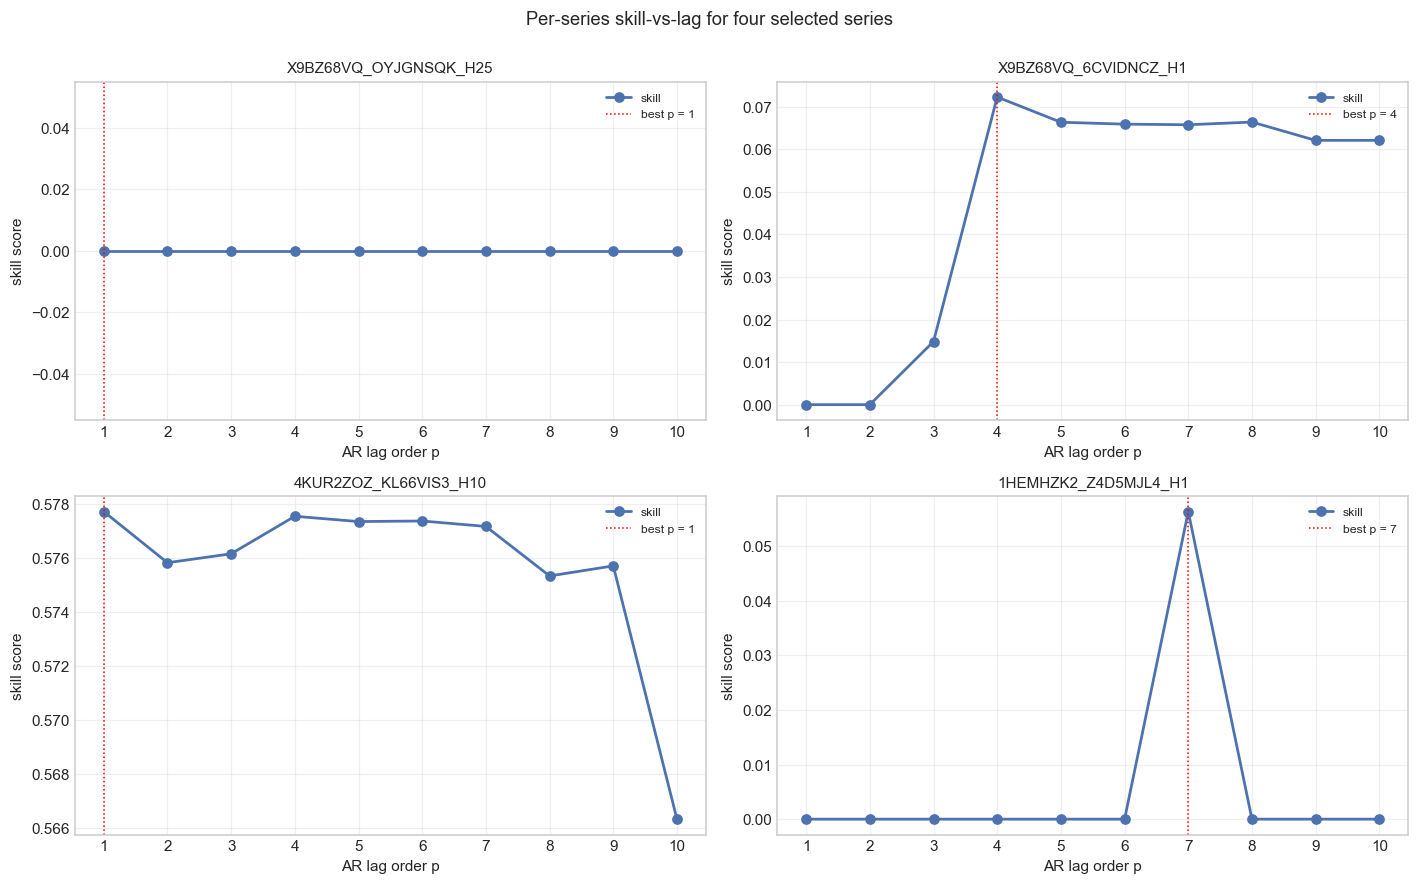

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, series_id in zip(axes, picks):
    sub = (ok[(ok['series'] == series_id) & (ok['model'].isin(ar_names))]
             .set_index('model').reindex(ar_names))
    p_vals = [int(m[3:-1]) for m in sub.index]
    ax.plot(p_vals, sub['skill_score'], marker='o', linewidth=1.8, color='#4C72B0', label='skill')
    best_p = int(sub['skill_score'].idxmax()[3:-1])
    ax.axvline(best_p, color='red', linestyle=':', linewidth=1, label=f'best p = {best_p}')
    ax.set_title(series_id, fontsize=10)
    ax.set_xlabel('AR lag order p')
    ax.set_ylabel('skill score')
    ax.set_xticks(range(1, 11))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Per-series skill-vs-lag for four selected series', y=1.00)
plt.tight_layout()
plt.show()

**Reading.** Each panel is one series' own AR lag curve.

- **Flat panels** (roughly horizontal) → adding lags does nothing for that series. Signal, if any, lives in lag 1. Naive-style forecasts are likely enough.
- **Peaked panels** (climb then fall) → classic overfitting. The red dotted "best p" line points to the sensible order for that series; anything past it is parameter waste.
- **Monotone panels** (still climbing at p = 10) → the series carries deep memory. Worth extending the grid further in a follow-up. For now we truncate at 10.

If all four panels agree on a best p, that p is a solid panel-wide default. If they disagree, the panel is heterogeneous and a per-series order selection strategy (like auto-ARIMA) would outperform any fixed choice.

## 6d. Forecast visualization — train / test / predict

For the same four series, plot the Texas-Oil-style view: training history, held-out truth, and the best-AR-lag prediction. Title reports the model chosen and its weighted skill score.

Important: the leaderboard score is an **open-loop multi-step forecast** from the end of the training window. For ARIMA(p,1,0), that can look almost linear because the model recursively forecasts future differences and integrates them back to levels. To make the AR dynamics visible, the plot also includes a **one-step-ahead validation diagnostic**: fit once on train, predict the next point, then update the state with the observed validation value without refitting parameters.

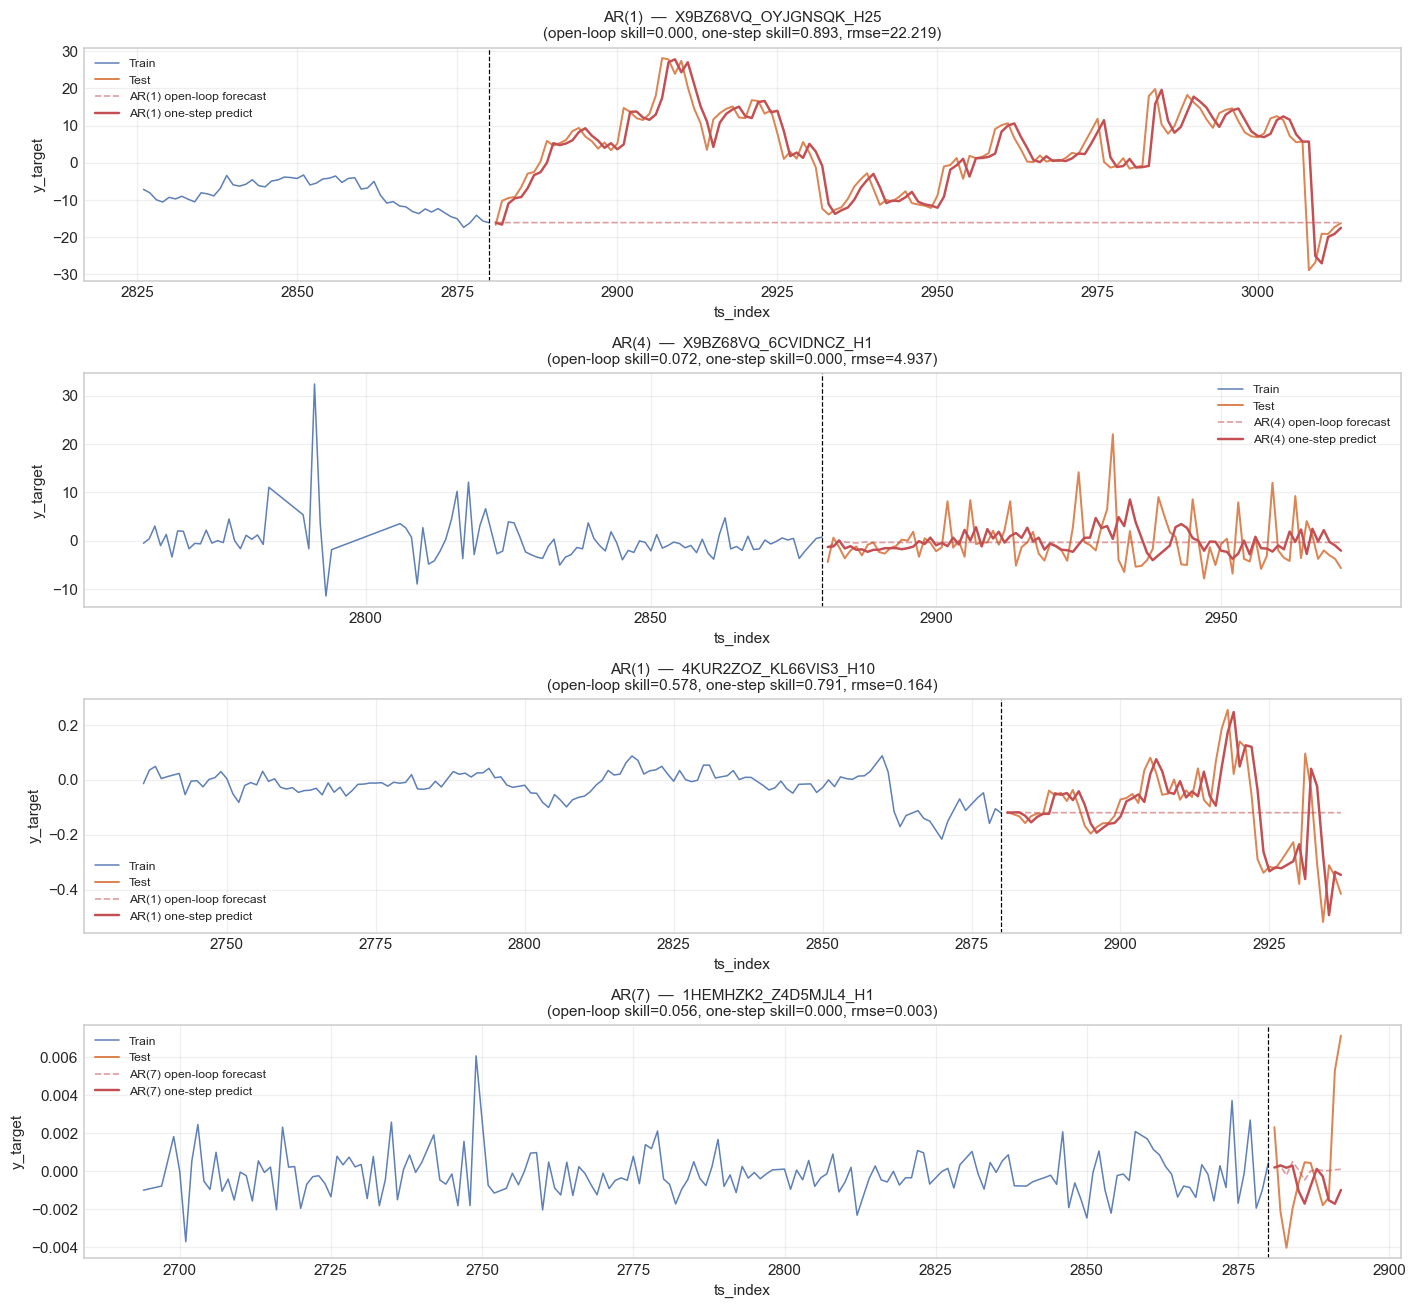

In [15]:
def fetch_series(series_id):
    row = ok[ok['series'] == series_id].iloc[0]
    class R:
        code = row['code']; sub_code = row['sub_code']
        sub_category = row['sub_category']; horizon = row['horizon']
    df = get_series_df(R())
    return split_series(df)

def arima_one_step_validation_predict(y_train, y_validation, order):
    """One-step validation predictions using fixed train-fitted parameters.

    This is a diagnostic curve, not a deployable multi-step forecast: after each
    one-step prediction, the observed validation value updates the state.
    """
    y_train = pd.Series(y_train, dtype=float).reset_index(drop=True)
    y_validation = np.asarray(y_validation, dtype=float)
    fit = ARIMA(y_train, order=order,
                enforce_stationarity=False,
                enforce_invertibility=False).fit()

    preds = []
    for actual in y_validation:
        preds.append(float(np.asarray(fit.forecast(1), dtype=float)[0]))
        fit = fit.append(pd.Series([float(actual)], index=[fit.nobs], name=y_train.name), refit=False)

    pred = np.asarray(preds, dtype=float)
    if not np.all(np.isfinite(pred)):
        raise ValueError('non-finite one-step forecast')
    return pred

fig, axes = plt.subplots(len(picks), 1, figsize=(13, 3.0 * len(picks)))
axes = np.atleast_1d(axes)

for ax, series_id in zip(axes, picks):
    sub = (ok[(ok['series'] == series_id) & (ok['model'].isin(ar_names))]
             .set_index('model').reindex(ar_names))
    best_model = sub['skill_score'].idxmax()
    best_p = int(best_model[3:-1])
    best_skill = float(sub.loc[best_model, 'skill_score'])
    best_rmse  = float(sub.loc[best_model, 'rmse'])

    tr, vl = fetch_series(series_id)
    y_tr = tr['y_target'].reset_index(drop=True)
    y_vl = vl['y_target'].to_numpy(dtype=float)
    w_vl = vl['weight'].to_numpy(dtype=float)
    open_loop_pred = MODEL_SPECS[best_model]['func'](y_tr, len(vl))
    one_step_pred = arima_one_step_validation_predict(y_tr, y_vl, order=(best_p, 1, 0))
    one_step_skill = weighted_skill(y_vl, one_step_pred, w_vl)

    ax.plot(tr['ts_index'], tr['y_target'], label='Train',          color='#4C72B0', linewidth=1.0, alpha=0.9)
    ax.plot(vl['ts_index'], vl['y_target'], label='Test',           color='#DD8452', linewidth=1.3)
    ax.plot(vl['ts_index'], open_loop_pred, label=f'{best_model} open-loop forecast',
            color='#C44E52', linestyle='--', linewidth=1.1, alpha=0.55)
    ax.plot(vl['ts_index'], one_step_pred,  label=f'{best_model} one-step predict',
            color='#C44E52', linewidth=1.6)
    ax.axvline(VAL_CUTOFF, color='black', linestyle='--', linewidth=0.8)

    ax.set_title(f'{best_model}  —  {series_id}\n(open-loop skill={best_skill:.3f}, one-step skill={one_step_skill:.3f}, rmse={best_rmse:.3f})',
                 fontsize=10)
    ax.set_xlabel('ts_index')
    ax.set_ylabel('y_target')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Reading.** Four checks per panel:

1. **Dashed red = deployable open-loop forecast.** This is the same object scored in §6c. If it looks linear, that is expected: after the forecast origin, ARIMA(p,1,0) has no new shocks, so the expected differences smooth out and their cumulative sum becomes a smooth level path.
2. **Solid red = one-step validation diagnostic.** This updates the model state with each observed validation value, so it shows whether the AR coefficients react sensibly to new information. It should be used for diagnosis, not as the leaderboard score.
3. **Does the forecast stay in the training range?** If either prediction drifts far outside the blue envelope, the AR coefficients have estimated an unstable process on differences — watch for this on high-p fits.
4. **Skill vs RMSE agreement.** Skill close to 1 with huge RMSE is a contradiction (or a degenerate near-constant series); skill close to 0 with tiny RMSE means the series itself is small-scale and the model is no better than predicting zero.

This visualization is the classical forecaster's sanity check — numbers in a table can mislead, but the train / test / predict plot almost never does.

## 6e. Loss vs lag — MA family scan

Same scan as §6b, but for the MA family. MA(q) captures short-memory shock dynamics on the differenced series — a different kind of information than AR(p)'s lagged-value dynamics. Plotting both on the same axis tells us which channel carries the panel's signal.

In [16]:
ma_models = [f'MA({q})' for q in range(1, 11)]

ma_scan = (
    ok[ok['model'].isin(ma_models)]
      .groupby('model')
      .agg(mean_skill=('skill_score', 'mean'),
           mean_rmse =('rmse',        'mean'),
           mean_mae  =('mae',         'mean'),
           mean_mase =('mase',        'mean'),
           n_ok      =('series',      'count'))
      .reindex(ma_models)
)
ma_scan.index = [int(m[3:-1]) for m in ma_scan.index]
ma_scan.index.name = 'q'
ma_scan

,mean_skill,mean_rmse,mean_mae,mean_mase,n_ok
q,,,,,
1,0.091090,7.136479e+00,5.884042e+00,3.485617e+00,171
2,0.093354,7.149368e+00,5.901514e+00,3.489390e+00,171
3,0.102737,7.072694e+00,5.843818e+00,3.387718e+00,171
4,0.094688,7.337042e+00,6.059825e+00,3.366104e+00,167
5,0.103304,7.327724e+00,6.077875e+00,3.317588e+00,166
6,0.103750,7.365931e+00,6.020981e+00,3.328969e+00,166
7,0.117584,5.274426e+00,4.215161e+00,3.251734e+00,161
8,0.115077,5.652492e+00,4.575605e+00,3.243152e+00,155
9,0.108507,6.121276e+00,4.976168e+00,3.103669e+00,147


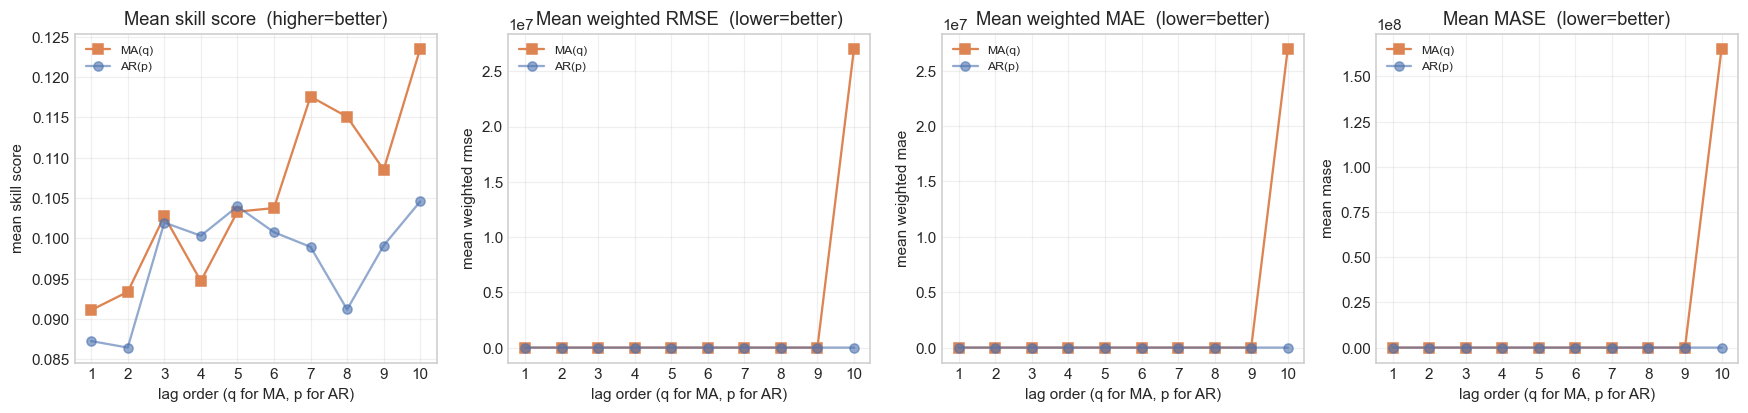

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col, title, higher_better in zip(
    axes,
    ['mean_skill', 'mean_rmse', 'mean_mae', 'mean_mase'],
    ['Mean skill score', 'Mean weighted RMSE', 'Mean weighted MAE', 'Mean MASE'],
    [True, False, False, False],
):
    ax.plot(ma_scan.index, ma_scan[col], marker='s', color='#DD8452', label='MA(q)')
    if 'ar_scan' in dir():
        ax.plot(ar_scan.index, ar_scan[col], marker='o', color='#4C72B0', alpha=0.6, label='AR(p)')
        ax.legend(fontsize=8)
    direction = 'higher=better' if higher_better else 'lower=better'
    ax.set_title(f'{title}  ({direction})')
    ax.set_xlabel('lag order (q for MA, p for AR)')
    ax.set_ylabel(title.lower())
    ax.set_xticks(range(1, 11))
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Reading.** Two things to spot:

- **Which family wins overall?** If AR's curve sits consistently above MA's on the skill panel (and below on RMSE/MAE/MASE), AR is the stronger channel for this panel. Classical wisdom says AR usually wins on finance-like data, but the panel may surprise us.
- **Shape comparison.** AR and MA can saturate at different lag orders. If AR saturates at p=2 and MA saturates at q=5, the panel has longer *shock memory* than *value memory* — relevant when designing ensemble features later.

## 6f. Loss vs total order — ARMA family scan

ARMA has two lag dimensions `(p, q)`, so the natural x-axis is **total order** `p + q`. We group the 10 ARMA variants by total order, average each loss across variants that share a total order, and plot the resulting curve. If adding complexity helps, skill rises monotonically with total order; if it overfits, the curve humps and then falls.

In [18]:
arma_labels = ['ARMA(1,1)', 'ARMA(2,1)', 'ARMA(1,2)', 'ARMA(2,2)',
               'ARMA(3,1)', 'ARMA(1,3)', 'ARMA(3,2)', 'ARMA(2,3)',
               'ARMA(3,3)', 'ARMA(4,4)']

def parse_arma(label):
    p, q = label[label.index('(')+1:label.index(')')].split(',')
    return int(p), int(q)

arma_rows = ok[ok['model'].isin(arma_labels)].copy()
arma_rows['p'] = arma_rows['model'].apply(lambda m: parse_arma(m)[0])
arma_rows['q'] = arma_rows['model'].apply(lambda m: parse_arma(m)[1])
arma_rows['total_order'] = arma_rows['p'] + arma_rows['q']

arma_scan = (
    arma_rows.groupby('total_order')
             .agg(mean_skill=('skill_score', 'mean'),
                  mean_rmse =('rmse',        'mean'),
                  mean_mae  =('mae',         'mean'),
                  mean_mase =('mase',        'mean'),
                  n_variants=('model', 'nunique'),
                  n_fits    =('model', 'count'))
)
arma_scan

,mean_skill,mean_rmse,mean_mae,mean_mase,n_variants,n_fits
total_order,,,,,,
2,0.089861,7.321061e+00,6.040469e+00,1.016135e+01,1,166
3,0.089826,inf,6.653787e+262,1.775007e+266,2,332
4,0.090553,2.316710e+05,5.894303e+04,2.792501e+07,3,483
5,0.089771,1.663697e+30,4.607779e+29,8.724372e+30,2,294
6,0.093810,6.360344e+00,5.223757e+00,3.309768e+00,1,147
8,0.114498,9.263991e+02,2.921566e+02,1.433367e+05,1,143


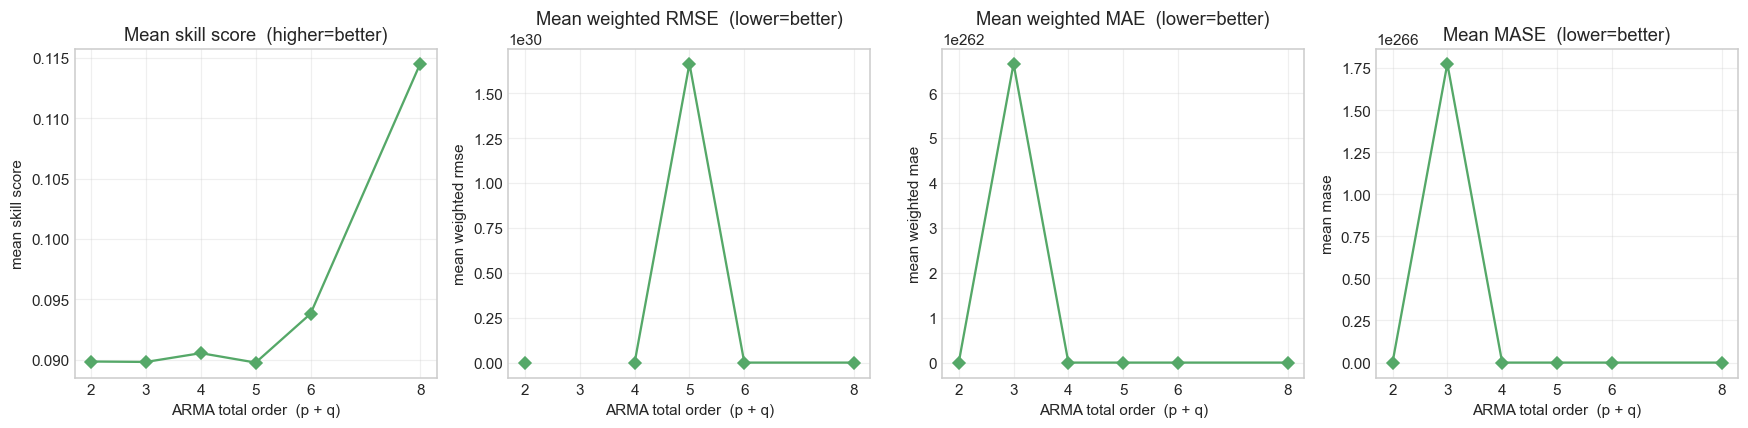

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col, title, higher_better in zip(
    axes,
    ['mean_skill', 'mean_rmse', 'mean_mae', 'mean_mase'],
    ['Mean skill score', 'Mean weighted RMSE', 'Mean weighted MAE', 'Mean MASE'],
    [True, False, False, False],
):
    ax.plot(arma_scan.index, arma_scan[col], marker='D', color='#55A868')
    direction = 'higher=better' if higher_better else 'lower=better'
    ax.set_title(f'{title}  ({direction})')
    ax.set_xlabel('ARMA total order  (p + q)')
    ax.set_ylabel(title.lower())
    ax.set_xticks(arma_scan.index)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Reading.** If the skill panel keeps climbing to total order 8, ARMA(4,4) is earning its 8 parameters. If it saturates at order 3 or 4, ARMA(1,1) or ARMA(2,2) is enough and the extra variants are vanity complexity. Compare with the AR scan in §6b and the MA scan in §6e — if ARMA(p+q = 2) ≈ AR(p=1) + MA(q=1), the joint model adds nothing beyond what either channel captures alone.

### 6g. Random series × (AR, MA, ARMA) — per-series loss curves

A panel mean can hide very different per-series behaviors. We pick four random series (same seed as the rest of the notebook) and overlay the AR, MA, and ARMA loss-vs-order curves on a single axis per series. Different series can reward different families — this plot makes that concrete.

In [20]:
rng_plot = np.random.default_rng(SEED)

# Only keep series where we got skill scores for all three families' scan models
ar_labels = [f'AR({p})' for p in range(1, 11)]
ma_labels = [f'MA({q})' for q in range(1, 11)]
scan_models = ar_labels + ma_labels + arma_labels

series_with_full = (
    ok[ok['model'].isin(scan_models)]
      .groupby('series')['model'].nunique()
)
complete = series_with_full[series_with_full == len(scan_models)].index.tolist()
print(f'Series with full AR+MA+ARMA coverage: {len(complete)}')

n_pick = min(4, len(complete))
if n_pick == 0:
    random_series = []
else:
    random_series = rng_plot.choice(complete, size=n_pick, replace=False).tolist()
print(f'Picked series: {random_series}')

Series with full AR+MA+ARMA coverage: 117
Picked series: ['K7Y1TTAH_9Y6B1JDN_H3', '660DZME0_6CVIDNCZ_H10', 'QAQDDTPJ_6CVIDNCZ_H25', 'VFWIFJPS_KL66VIS3_H10']


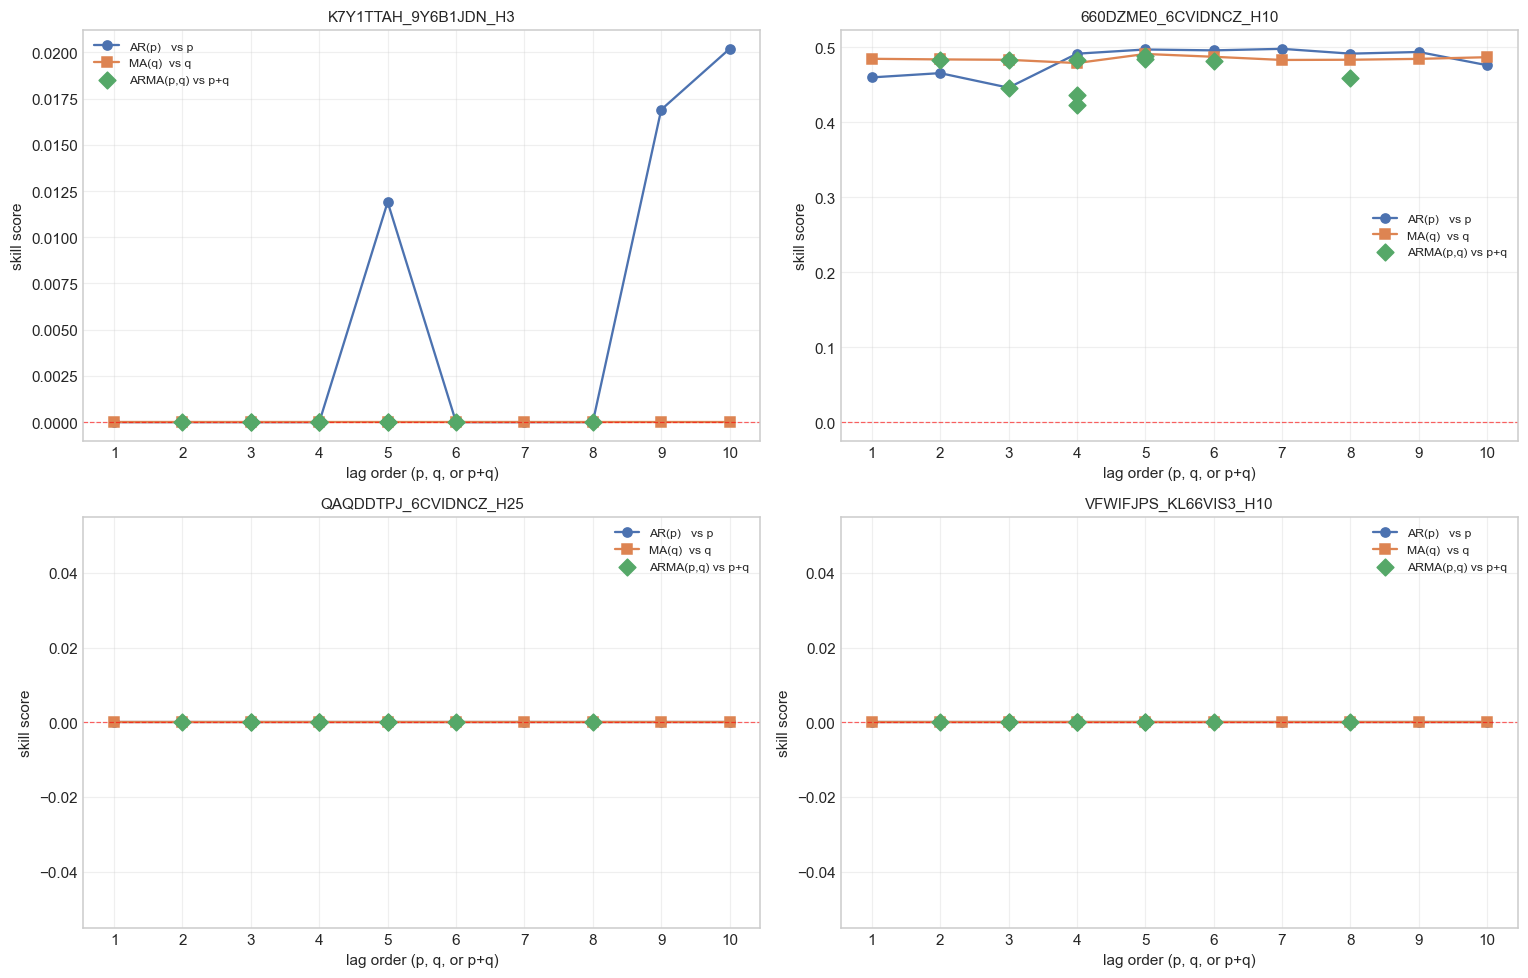

In [21]:
if not random_series:
    print('No series had coverage across all scan models — skipping plot.')
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()
    for ax, sid in zip(axes, random_series):
        sub = ok[ok['series'] == sid].set_index('model')

        # AR: skill at each p = 1..10
        ar_x, ar_y = [], []
        for p in range(1, 11):
            m = f'AR({p})'
            if m in sub.index:
                ar_x.append(p); ar_y.append(sub.loc[m, 'skill_score'])

        # MA: skill at each q = 1..10
        ma_x, ma_y = [], []
        for q in range(1, 11):
            m = f'MA({q})'
            if m in sub.index:
                ma_x.append(q); ma_y.append(sub.loc[m, 'skill_score'])

        # ARMA: one dot per variant at x = p + q
        arma_x, arma_y = [], []
        for label in arma_labels:
            if label in sub.index:
                p, q = parse_arma(label)
                arma_x.append(p + q); arma_y.append(sub.loc[label, 'skill_score'])

        ax.plot(ar_x, ar_y, marker='o', color='#4C72B0', label='AR(p)   vs p')
        ax.plot(ma_x, ma_y, marker='s', color='#DD8452', label='MA(q)  vs q')
        ax.scatter(arma_x, arma_y, marker='D', s=60, color='#55A868', label='ARMA(p,q) vs p+q', zorder=5)
        ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.set_title(sid, fontsize=10)
        ax.set_xlabel('lag order (p, q, or p+q)')
        ax.set_ylabel('skill score')
        ax.set_xticks(range(1, 11))
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='best')

    plt.tight_layout()
    plt.show()

**Reading.** Four honest checks per panel:

- **Do AR and MA curves agree?** If yes, both channels extract similar information from the differenced series. If one dominates the other, that family wins for this series.
- **Where does AR peak?** Look at the x-value of the highest blue point. That's the per-series optimal AR order — may differ from the panel-mean optimum in §6b.
- **Do ARMA diamonds sit above both AR and MA?** If yes, the joint model adds value. If they sit roughly on the AR line at same `p+q`, the MA terms aren't contributing.
- **Is there any positive skill at all?** If all three curves hug the red dashed zero line, this series has no univariate signal and classical methods won't help — the ensemble will need cross-series features.

## 7. Per-series winner analysis

For each series, pick the model with the highest skill. Then count how often each model wins.

In [22]:
winners = (
    ok.loc[ok.groupby('series')['skill_score'].idxmax(), ['series', 'sub_category', 'horizon', 'model', 'skill_score']]
      .rename(columns={'model': 'winner', 'skill_score': 'winning_skill'})
      .reset_index(drop=True)
)

winner_counts = (
    winners.groupby('winner')
           .agg(n_series=('series', 'count'),
                mean_winning_skill=('winning_skill', 'mean'))
           .sort_values('n_series', ascending=False)
)
winner_counts['share'] = winner_counts['n_series'] / winner_counts['n_series'].sum()
winner_counts.round(4)

,n_series,mean_winning_skill,share
winner,,,
Zero,50,0.0000,0.2976
Rolling Mean (w=10),12,0.3460,0.0714
Expanding Mean,9,0.2323,0.0536
"SARIMA(1,1,1)(1,1,1,7)",8,0.4337,0.0476
Drift,8,0.3668,0.0476
AR(5),8,0.3334,0.0476
"SARIMA(1,1,1)(1,1,1,24)",7,0.5213,0.0417
"ARIMA(2,0,2)",6,0.4623,0.0357
MA(10),6,0.5642,0.0357


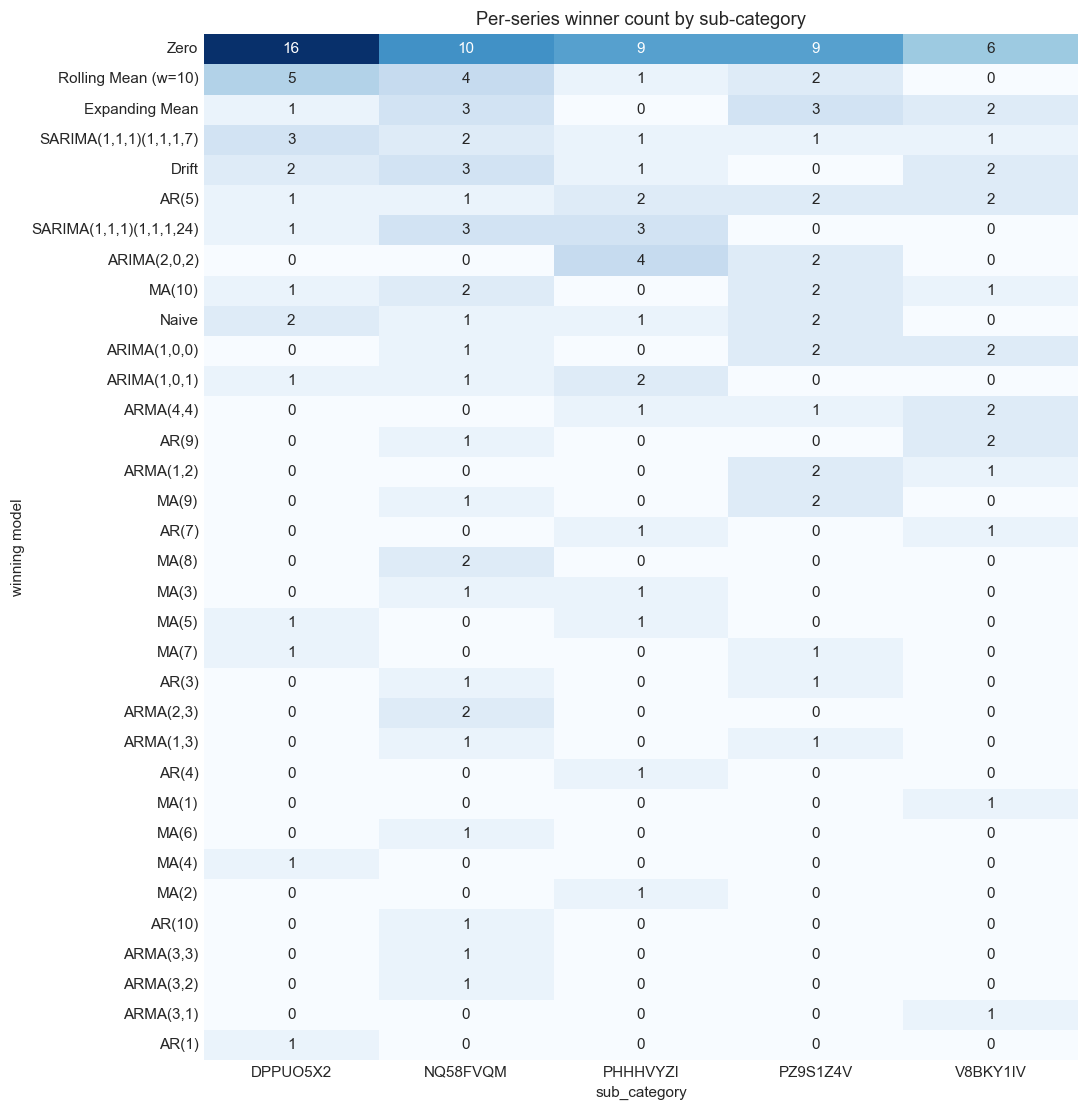

In [23]:
# heatmap: winner x sub_category
heat = winners.pivot_table(index='winner', columns='sub_category', values='series', aggfunc='count', fill_value=0)
# reorder rows by total wins
heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(heat))))
sns.heatmap(heat, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('Per-series winner count by sub-category')
ax.set_ylabel('winning model')
plt.tight_layout()
plt.show()

**Reading.** If one model dominates every column, it's a robust panel winner. If different sub-categories pick different winners, a **per-series selection** ensemble (planned in `05_ensemble_hybrid.ipynb`) has real room to beat any single model.

## 8. d=0 vs d=1 ARIMA head-to-head — the §11 test

EDA §11 showed 100% of series become stationary after first differencing. If that finding is load-bearing, `d=1` should beat `d=0` on a matched-pair comparison. We pick two pairs:

- **AR(1) on diff** (= ARIMA(1,1,0)) vs **ARIMA(1,0,0)** — pure AR
- **ARMA(1,1) on diff** (= ARIMA(1,1,1)) vs **ARIMA(1,0,1)** — mixed

For each pair, we plot one point per series with `skill_d0` on the x-axis and `skill_d1` on the y-axis, plus the 45° line. If the EDA was right, most points lie **above** the line.

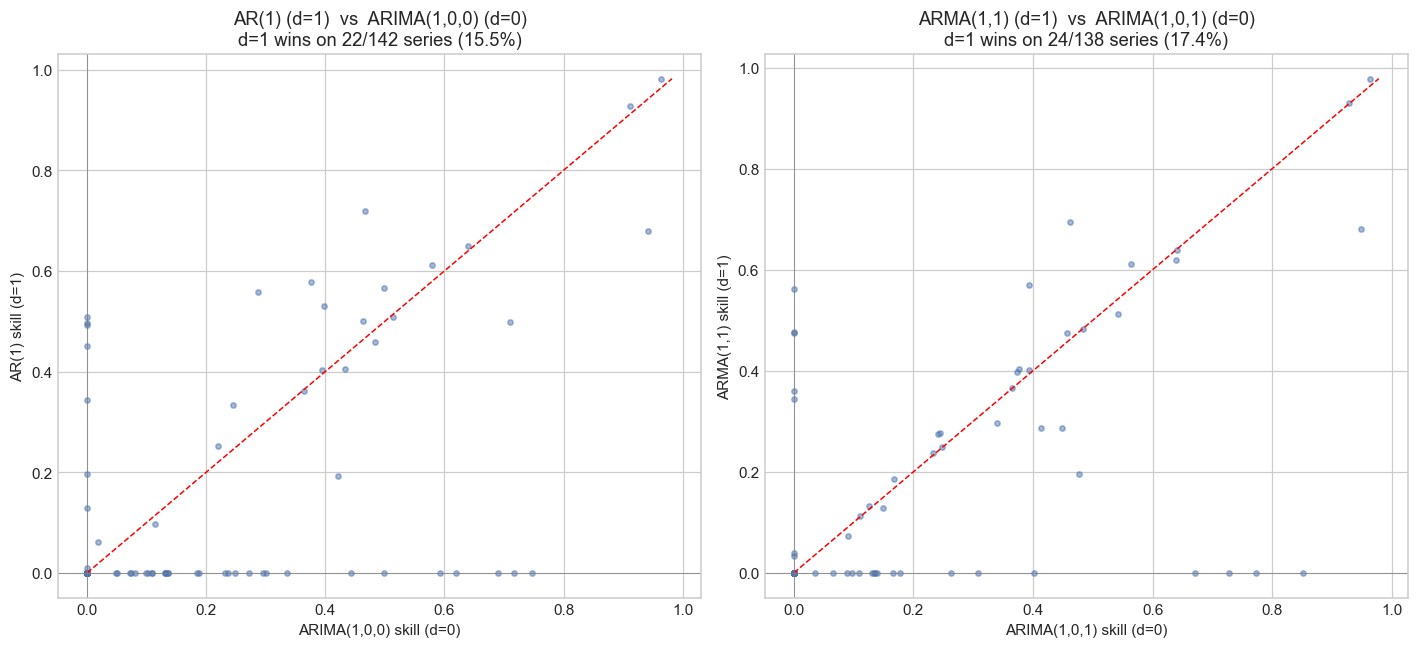

In [24]:
def paired_skills(d1_model, d0_model):
    p = ok[ok['model'].isin([d0_model, d1_model])].pivot_table(
        index='series', columns='model', values='skill_score', aggfunc='first')
    return p.dropna()

pairs = [('AR(1)', 'ARIMA(1,0,0)'), ('ARMA(1,1)', 'ARIMA(1,0,1)')]
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (d1_name, d0_name) in zip(axes, pairs):
    p = paired_skills(d1_name, d0_name)
    if p.empty:
        ax.set_title(f'No paired data for {d1_name} vs {d0_name}')
        continue
    ax.scatter(p[d0_name], p[d1_name], s=12, alpha=0.5, color='#4C72B0')
    lo = min(p[d0_name].min(), p[d1_name].min())
    hi = max(p[d0_name].max(), p[d1_name].max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    wins_d1 = int((p[d1_name] > p[d0_name]).sum())
    ax.set_title(f'{d1_name} (d=1)  vs  {d0_name} (d=0)\nd=1 wins on {wins_d1}/{len(p)} series ({wins_d1/len(p):.1%})')
    ax.set_xlabel(f'{d0_name} skill (d=0)')
    ax.set_ylabel(f'{d1_name} skill (d=1)')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)
plt.tight_layout()
plt.show()

**Reading.** If d=1 wins on more than half the series, the EDA conclusion holds for practical forecasting, not just for the ADF test statistic. If d=0 wins comparably, the stationarity-on-differences finding didn't translate into predictive advantage — worth understanding before trusting d=1 as a default everywhere.

## 9. Breakdown by horizon

Classical models usually degrade as horizon grows — extrapolation noise compounds. The horizon × model heatmap surfaces that pattern.

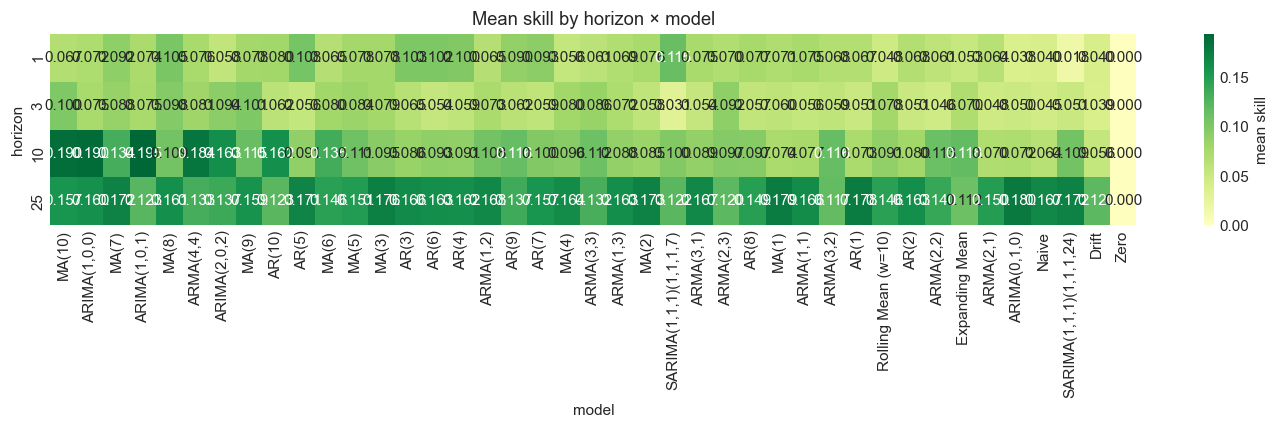

In [25]:
horizon_tbl = (
    ok.groupby(['horizon', 'model'])['skill_score']
      .mean().unstack('model').reindex(columns=order)
)
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(horizon_tbl, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax,
            cbar_kws={'label': 'mean skill'})
ax.set_title('Mean skill by horizon × model')
plt.tight_layout()
plt.show()

## 10. Breakdown by sub-category

Same view but for sub-categories. Tells us whether a model is a general winner or only works in specific panel slices.

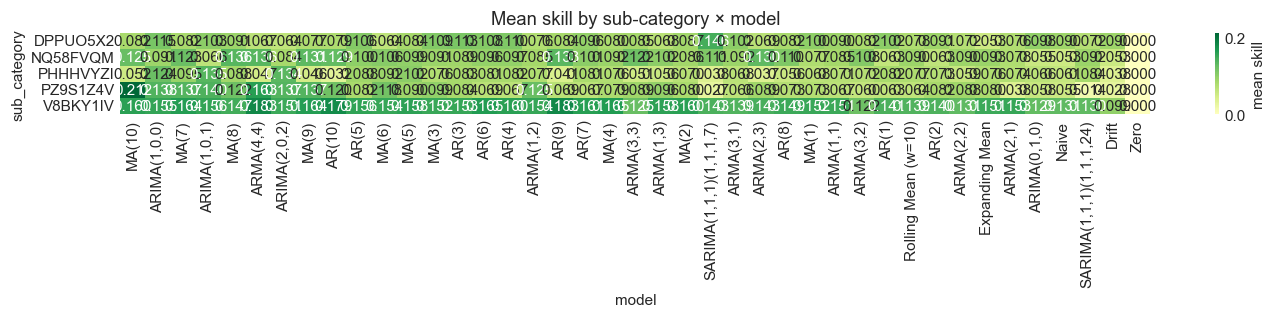

In [26]:
subcat_tbl = (
    ok.groupby(['sub_category', 'model'])['skill_score']
      .mean().unstack('model').reindex(columns=order)
)
fig, ax = plt.subplots(figsize=(13, max(3, 0.3 * subcat_tbl.shape[0])))
sns.heatmap(subcat_tbl, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax,
            cbar_kws={'label': 'mean skill'})
ax.set_title('Mean skill by sub-category × model')
plt.tight_layout()
plt.show()

## 11. Failure / skip analysis

Makes coverage honest. A model that wins on the series it fits but silently skips 30% of the panel is not actually a strong baseline — the ensemble needs full coverage or explicit fallbacks.

In [27]:
status_tbl = results.groupby(['model', 'status']).size().unstack(fill_value=0)
status_tbl['coverage'] = status_tbl.get('ok', 0) / status_tbl.sum(axis=1)
status_tbl.sort_values('coverage', ascending=False)

status,failed,ok,skipped,coverage
model,,,,
Zero,0,200,0,1.000
Naive,0,200,0,1.000
Expanding Mean,0,200,0,1.000
Rolling Mean (w=10),0,197,3,0.985
Drift,0,197,3,0.985
"ARIMA(1,0,0)",0,171,29,0.855
MA(3),0,171,29,0.855
MA(2),0,171,29,0.855
MA(1),0,171,29,0.855


In [28]:
reasons = (
    results[results['status'] != 'ok']
           .groupby(['model', 'status', 'skip_reason'])
           .size().reset_index(name='count')
           .sort_values(['model', 'count'], ascending=[True, False])
)
reasons.head(30)

,model,status,skip_reason,count
0,AR(1),skipped,train_len<25,29
1,AR(10),skipped,train_len<40,53
2,AR(2),skipped,train_len<25,29
3,AR(3),skipped,train_len<25,29
4,AR(4),skipped,train_len<28,33
5,AR(5),skipped,train_len<30,34
6,AR(6),skipped,train_len<32,34
7,AR(7),skipped,train_len<34,39
8,AR(8),skipped,train_len<36,45
9,AR(9),skipped,train_len<38,53


## 12. Case studies

Instead of "best" / "worst" (degenerate picks), we choose series that teach something:

1. **ARMA(1,1) wins big** — serial structure is real and classical ARMA captures it.
2. **Naive wins** — persistence is all there is; anything fancier overfits.
3. **All models tied near 0** — pure noise, no univariate signal.
4. **d=0 beats d=1** — the EDA-contradicting case. Worth staring at.

In [29]:
# Pick one series per case, where possible
def pick_case(condition_df, label):
    if len(condition_df) == 0:
        return None
    row = condition_df.iloc[0]
    return {'case': label, 'series': row['series']}

case_defs = []

# 1. ARMA(1,1) wins big
c = (ok.loc[ok.groupby('series')['skill_score'].idxmax()]
       .query("model == 'ARMA(1,1)' and skill_score > 0.3")
       .sort_values('skill_score', ascending=False))
case_defs.append(pick_case(c, 'ARMA(1,1) wins big'))

# 2. Naive wins
c = (ok.loc[ok.groupby('series')['skill_score'].idxmax()]
       .query("model == 'Naive' and skill_score > 0.2")
       .sort_values('skill_score', ascending=False))
case_defs.append(pick_case(c, 'Naive wins'))

# 3. All models tied near 0
near_zero = ok.groupby('series')['skill_score'].max().reset_index()
near_zero = near_zero[near_zero['skill_score'] < 0.01]
case_defs.append(pick_case(near_zero.rename(columns={'skill_score': 'dummy'}), 'all models near 0'))

# 4. d=0 beats d=1 (ARMA(1,1) vs ARIMA(1,0,1))
paired = paired_skills('ARMA(1,1)', 'ARIMA(1,0,1)')
d0_wins = paired[paired['ARIMA(1,0,1)'] > paired['ARMA(1,1)'] + 0.1]
if len(d0_wins):
    case_defs.append({'case': 'd=0 beats d=1', 'series': d0_wins.index[0]})

case_defs = [c for c in case_defs if c is not None]
case_df = pd.DataFrame(case_defs)
case_df

,case,series
0,Naive wins,QAQDDTPJ_OYJGNSQK_H25
1,all models near 0,10BAVIDU_9Y6B1JDN_H25
2,d=0 beats d=1,1HEMHZK2_5AIUJMDO_H10


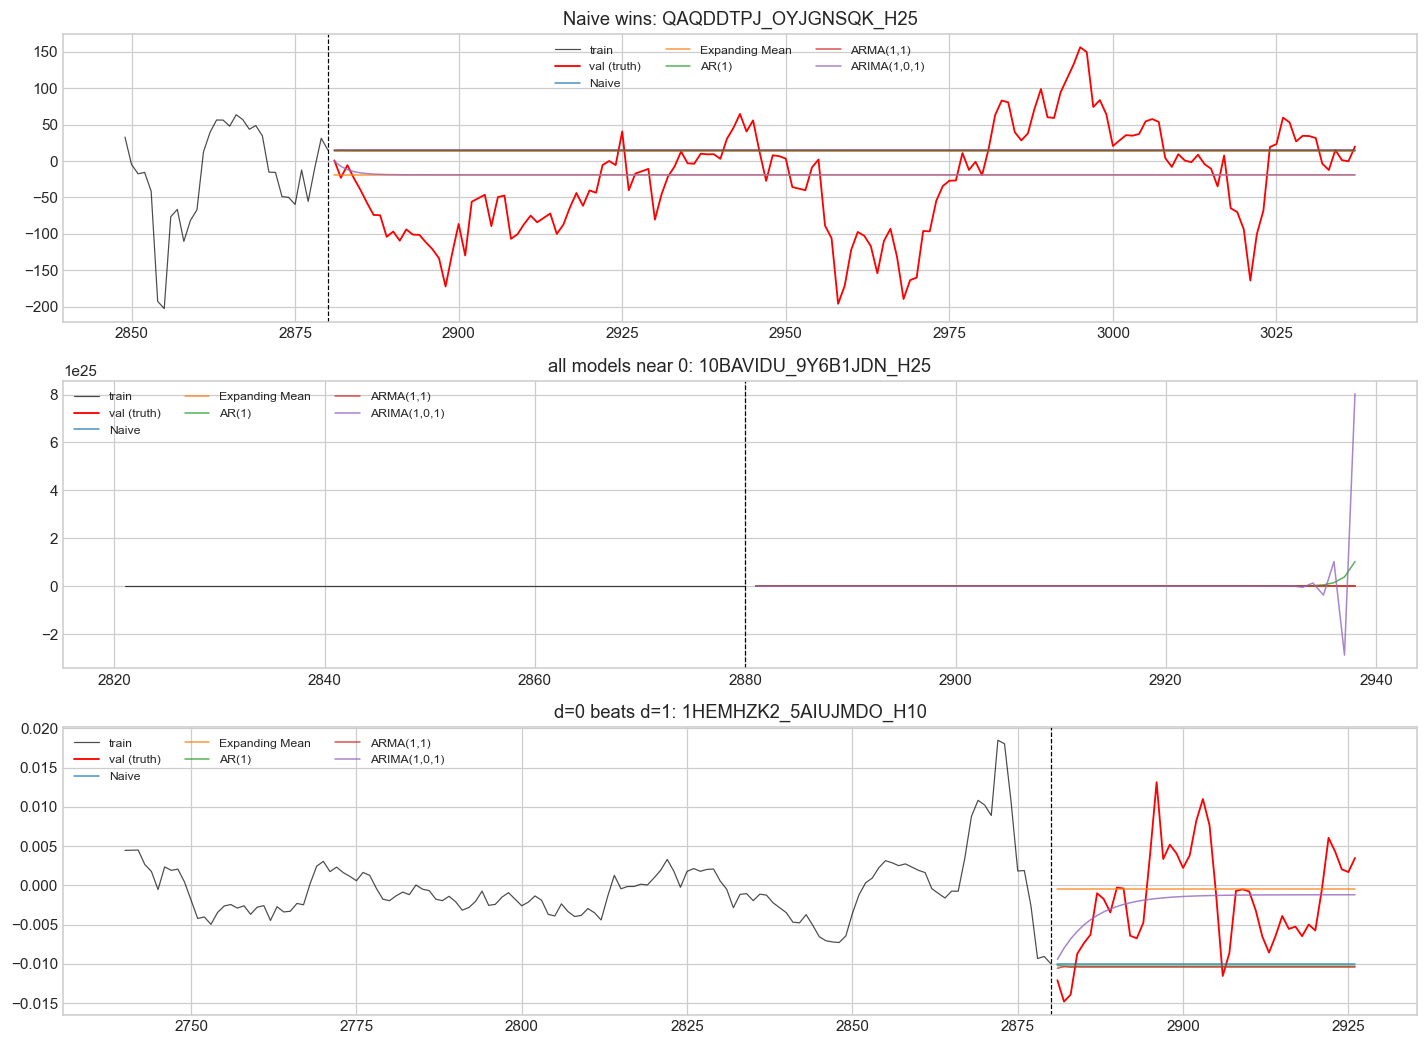

In [30]:
# Plot each case: training + validation + a few model forecasts
plot_models = ['Naive', 'Expanding Mean', 'AR(1)', 'ARMA(1,1)', 'ARIMA(1,0,1)']

def refit_forecasts(series_id):
    code_, sub_, h_ = None, None, None
    # parse series_id back
    parts = series_id.rsplit('_H', 1)
    left, h_ = parts[0], int(parts[1])
    code_, sub_ = left.split('_', 1)
    meta_row = eligible_meta.query("code == @code_ and sub_code == @sub_ and horizon == @h_").iloc[0]

    class R:  # tiny namespace mimic for get_series_df
        code=meta_row['code']; sub_code=meta_row['sub_code']
        sub_category=meta_row['sub_category']; horizon=meta_row['horizon']
    df = get_series_df(R())
    tr, vl = split_series(df)
    y_tr = tr['y_target'].reset_index(drop=True)
    steps = len(vl)
    preds = {}
    for m in plot_models:
        try:
            preds[m] = MODEL_SPECS[m]['func'](y_tr, steps)
        except Exception:
            preds[m] = None
    return tr, vl, preds, meta_row

fig, axes = plt.subplots(len(case_df), 1, figsize=(13, 3.2 * len(case_df)))
axes = np.atleast_1d(axes)
for ax, row in zip(axes, case_df.itertuples(index=False)):
    try:
        tr, vl, preds, meta_row = refit_forecasts(row.series)
    except Exception as e:
        ax.set_title(f'{row.case}: could not plot ({e})')
        continue
    ax.plot(tr['ts_index'], tr['y_target'], color='black', linewidth=0.8, label='train', alpha=0.7)
    ax.plot(vl['ts_index'], vl['y_target'], color='red', linewidth=1.2, label='val (truth)')
    for m, p in preds.items():
        if p is not None:
            ax.plot(vl['ts_index'], p, alpha=0.8, linewidth=1, label=m)
    ax.axvline(VAL_CUTOFF, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{row.case}: {row.series}')
    ax.legend(fontsize=8, loc='best', ncol=3)
plt.tight_layout()
plt.show()

## 12b. Per-model forecast plots — train vs test vs prediction

For one clear anchor series, plot each of a handful of models the way classical time-series papers do it: **train (blue), test truth (orange), model prediction (red)**, with the model name and skill score in the title. This makes differences between families visible in a way the leaderboard table cannot.

In [31]:
# Pick one anchor series: longest in the sample
anchor_row = sampled_meta.sort_values('length', ascending=False).iloc[0]
anchor_df = get_series_df(anchor_row)
anchor_train, anchor_val = split_series(anchor_df)
y_tr = anchor_train['y_target'].reset_index(drop=True)
y_vl = anchor_val['y_target'].to_numpy(dtype=float)
w_vl = anchor_val['weight'].to_numpy(dtype=float)
steps = len(anchor_val)
anchor_name = f"{anchor_row['code']}_{anchor_row['sub_code']}_H{int(anchor_row['horizon'])}"
print(f'Anchor series: {anchor_name}  (train_len={len(y_tr)}, val_len={steps})')

plot_models_12b = ['Naive', 'Drift', 'AR(1)', 'AR(3)', 'AR(10)', 'MA(1)', 'ARMA(1,1)', 'ARIMA(0,1,0)']
forecasts_12b = {}
for m in plot_models_12b:
    spec = MODEL_SPECS[m]
    if len(y_tr) < spec['min_train']:
        forecasts_12b[m] = None
        continue
    try:
        forecasts_12b[m] = np.asarray(spec['func'](y_tr, steps), dtype=float)
    except Exception as e:
        print(f'  {m} failed: {type(e).__name__}')
        forecasts_12b[m] = None

Anchor series: X9BZ68VQ_OYJGNSQK_H1  (train_len=55, val_len=157)


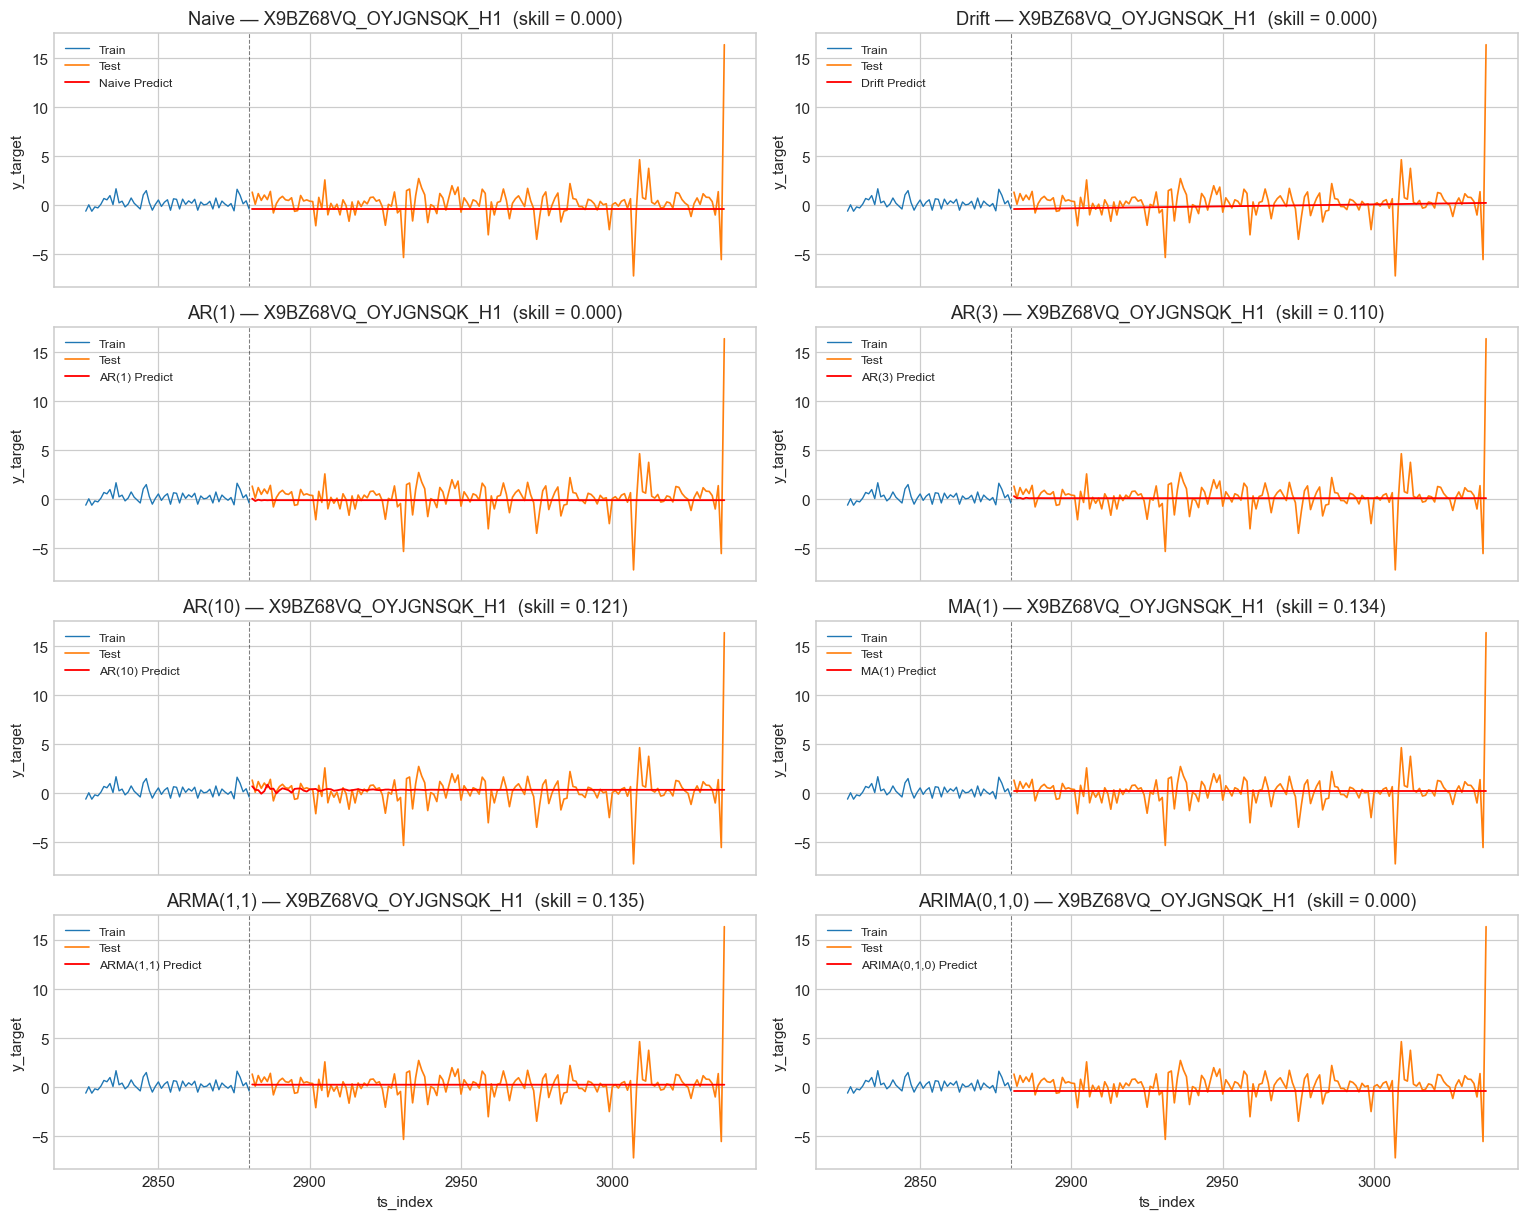

In [32]:
n_models = len(plot_models_12b)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.8 * n_rows), sharex=True)
axes = np.atleast_1d(axes).flatten()

for ax, m in zip(axes, plot_models_12b):
    pred = forecasts_12b.get(m)
    ax.plot(anchor_train['ts_index'], anchor_train['y_target'], color='#1f77b4', linewidth=0.9, label='Train')
    ax.plot(anchor_val['ts_index'],   anchor_val['y_target'],   color='#ff7f0e', linewidth=1.1, label='Test')
    if pred is not None:
        skill = weighted_skill(y_vl, pred, w_vl)
        ax.plot(anchor_val['ts_index'], pred, color='red', linewidth=1.2, label=f'{m} Predict')
        ax.set_title(f'{m} — {anchor_name}  (skill = {skill:.3f})')
    else:
        ax.set_title(f'{m} — {anchor_name}  (skipped or failed)')
    ax.axvline(VAL_CUTOFF, color='black', linestyle='--', linewidth=0.7, alpha=0.5)
    ax.set_ylabel('y_target')
    ax.legend(fontsize=8, loc='best')

for ax in axes[n_models:]:
    ax.set_visible(False)
axes[-1].set_xlabel('ts_index')
axes[-2].set_xlabel('ts_index')
plt.tight_layout()
plt.show()

**Reading.**

- **Naive / ARIMA(0,1,0)** — flat red line at the last training value. If that already looks close to the orange truth, persistence is hard to beat on this series.
- **Drift** — red line with a slope matching the first-to-last training change. When the validation period keeps that trend, it wins; when the trend reverses, it fails.
- **AR(p) curves** — should hug the last training value but oscillate slightly based on lag coefficients. Higher p usually doesn't help visibly on one series — that's §6b's finding in picture form.
- **ARMA(1,1)** — similar to AR(1) but can react to the *last shock*, not just the last value. Often subtly different from AR(1) early in the validation region.

The skill number in each title ranks the models on this one series. Compare with §6's leaderboard — a match means this series is typical; a mismatch means the series is an exception the panel-wide average is smoothing over.

In [4]:
series_stats = (
    train.groupby(series_keys)
         .agg(length=('ts_index', 'size'),
              start=('ts_index', 'min'),
              end=('ts_index', 'max'),
              total_weight=('weight', 'sum'),
              target_std=('y_target', 'std'))
         .reset_index()
)
series_stats['crosses_cutoff'] = (series_stats['start'] <= VAL_CUTOFF) & (series_stats['end'] > VAL_CUTOFF)

print(f'Total series: {len(series_stats)}')
print(f'Series crossing VAL_CUTOFF={VAL_CUTOFF}: {series_stats["crosses_cutoff"].sum()}')
series_stats[['length', 'start', 'end']].describe().T

Total series: 36923
Series crossing VAL_CUTOFF=2880: 1930


,count,mean,std,min,25%,50%,75%,max
length,36923.0,144.555264,56.770160,1.0,104.0,166.0,194.0,213.0
start,36923.0,1894.655716,1045.470184,1.0,1031.0,1968.0,2787.0,3600.0
end,36923.0,2046.371124,1045.023400,1.0,1181.0,2127.0,2948.0,3601.0


In [5]:
eligible = series_stats[(series_stats['crosses_cutoff']) & (series_stats['length'] >= 120)].copy()
eligible['target_std'] = eligible['target_std'].fillna(0.0)
stable_pool = eligible[eligible['target_std'] > 0]

chosen = pd.concat([
    eligible.nlargest(1, 'length').assign(reason='longest history'),
    eligible.nlargest(1, 'total_weight').assign(reason='highest total weight'),
    eligible.nlargest(1, 'target_std').assign(reason='most volatile'),
    stable_pool.nsmallest(1, 'target_std').assign(reason='most stable'),
], ignore_index=True).drop_duplicates(subset=series_keys)

chosen[[*series_keys, 'reason', 'length', 'total_weight', 'target_std']]

,code,sub_code,sub_category,horizon,reason,length,total_weight,target_std
0,X9BZ68VQ,OYJGNSQK,DPPUO5X2,1,longest history,212,9.060035e+02,2.641558
1,SJZP0OVU,OYJGNSQK,NQ58FVQM,25,highest total weight,156,4.349747e+10,0.000394
2,W4S29LF4,KL66VIS3,PHHHVYZI,25,most volatile,162,4.562944e-01,296.760011
3,SJZP0OVU,OYJGNSQK,NQ58FVQM,1,most stable,170,3.869062e+10,0.000139



Processing: longest history
Train: 55, Val: 157


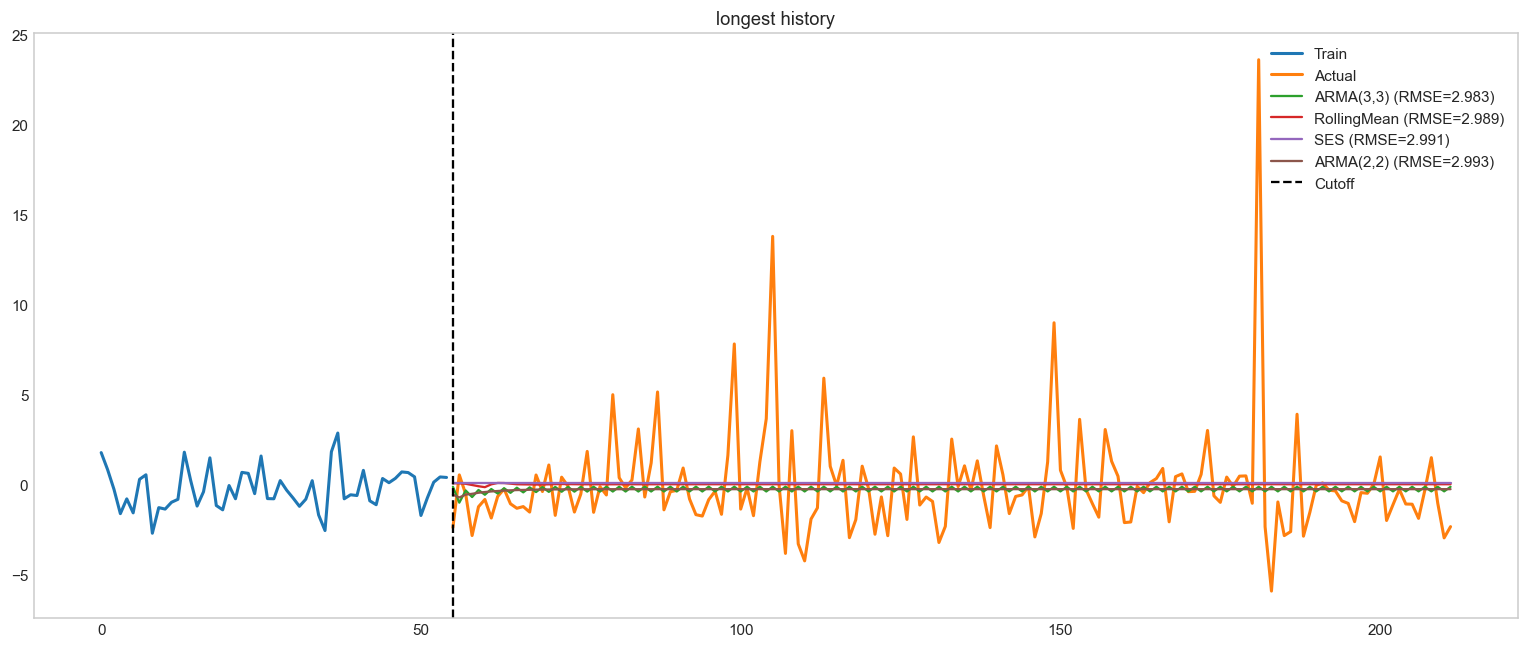


Processing: highest total weight
Train: 7, Val: 149


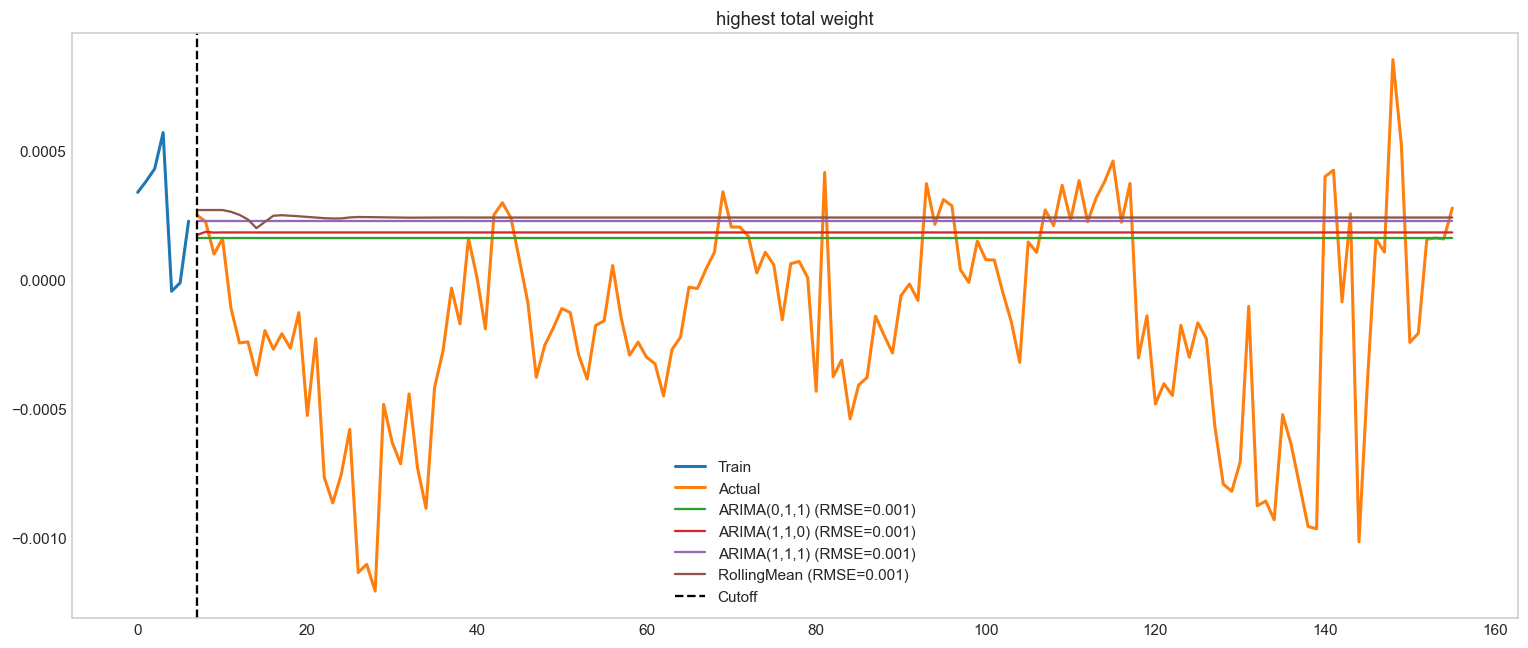


Processing: most volatile
Train: 131, Val: 31


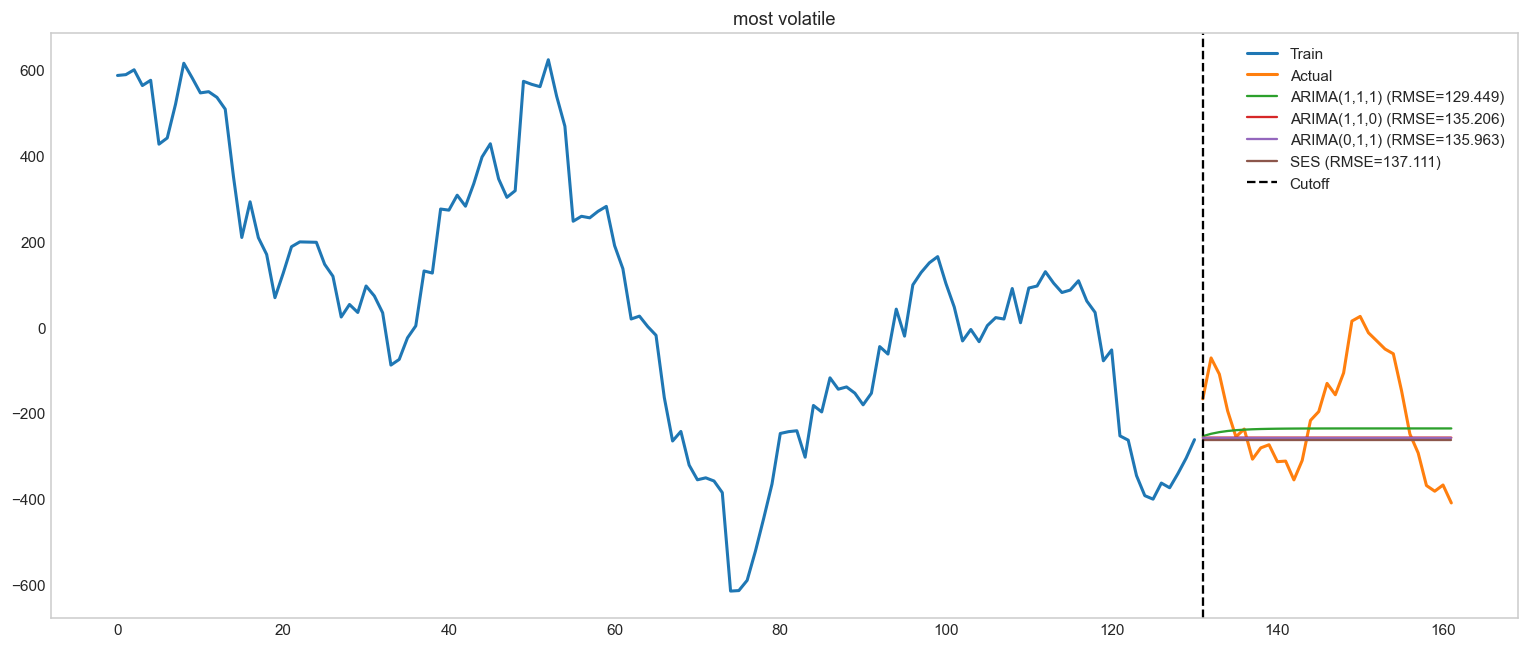


Processing: most stable
Train: 7, Val: 163


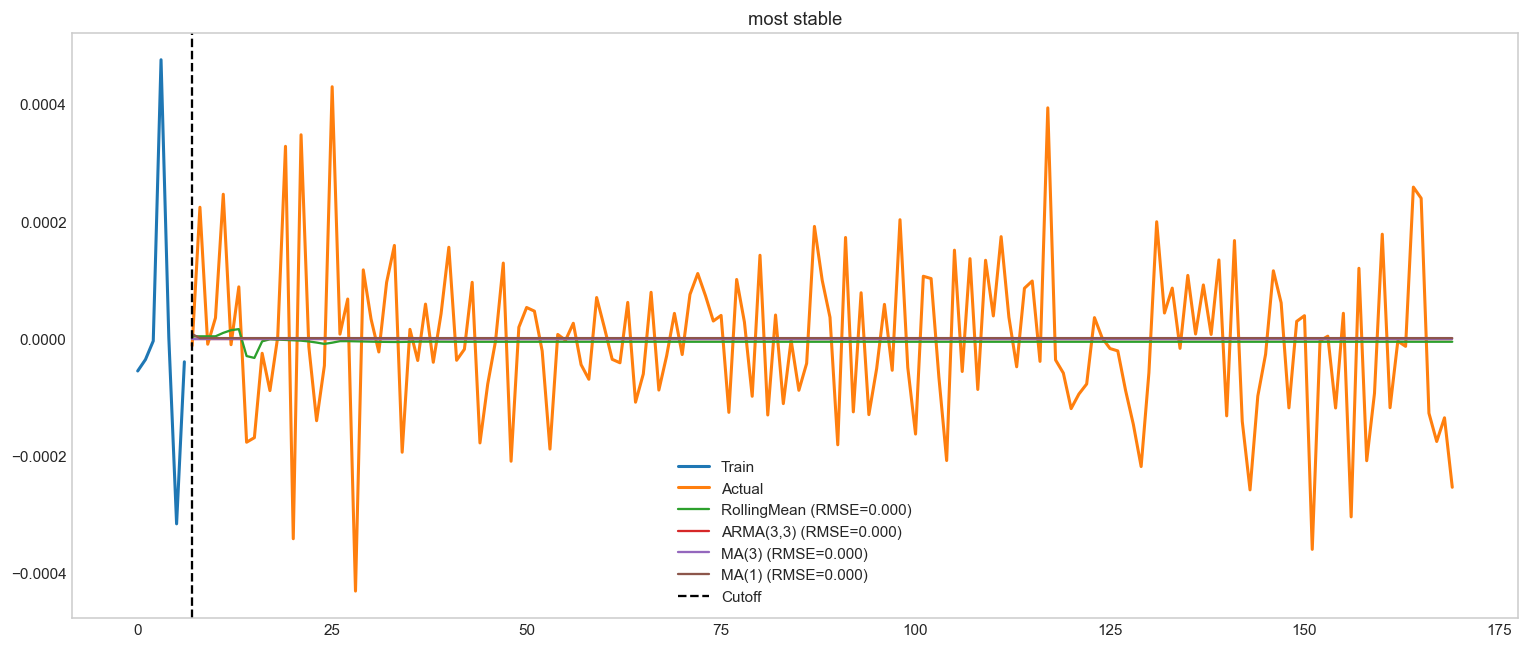


Top models per series:
                  reason         model        rmse
4   highest total weight  ARIMA(0,1,1)    0.000507
5   highest total weight  ARIMA(1,1,0)    0.000521
6   highest total weight  ARIMA(1,1,1)    0.000551
7   highest total weight   RollingMean    0.000561
0        longest history     ARMA(3,3)    2.983464
1        longest history   RollingMean    2.989394
2        longest history           SES    2.991186
3        longest history     ARMA(2,2)    2.993081
12           most stable   RollingMean    0.000134
13           most stable     ARMA(3,3)    0.000134
14           most stable         MA(3)    0.000134
15           most stable         MA(1)    0.000134
8          most volatile  ARIMA(1,1,1)  129.449016
9          most volatile  ARIMA(1,1,0)  135.205727
10         most volatile  ARIMA(0,1,1)  135.963423
11         most volatile           SES  137.110678


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt
from statsmodels.tsa.arima.model import ARIMA

# -------------------------------
# 1. Helper: extract series using cutoff
# -------------------------------
def get_series_cutoff(df, row, series_keys, cutoff):
    mask = np.ones(len(df), dtype=bool)
    for key in series_keys:
        mask &= df[key] == row[key]

    subset = df.loc[mask].sort_values('ts_index')

    train = subset[subset['ts_index'] <= cutoff]['y_target'].reset_index(drop=True)
    val   = subset[subset['ts_index'] > cutoff]['y_target'].reset_index(drop=True)

    return train, val


# -------------------------------
# 2. Models
# -------------------------------
def rolling_mean_forecast(train, steps, window=10):
    preds = []
    history = list(train)

    for _ in range(steps):
        preds.append(np.mean(history[-window:]))
        history.append(preds[-1])

    return np.array(preds)


def ses_forecast(train, steps):
    model = SimpleExpSmoothing(train).fit()
    return model.forecast(steps)


def holt_forecast(train, steps):
    model = Holt(train).fit()
    return model.forecast(steps)


def arima_forecast(train, steps, order):
    model = ARIMA(train, order=order).fit()
    return model.forecast(steps)


# -------------------------------
# 3. Model dictionary
# -------------------------------
models = {
    "RollingMean": lambda tr, n: rolling_mean_forecast(tr, n),
    "SES": lambda tr, n: ses_forecast(tr, n),
    "Holt": lambda tr, n: holt_forecast(tr, n),

    "AR(1)": lambda tr, n: arima_forecast(tr, n, (1,0,0)),
    "AR(2)": lambda tr, n: arima_forecast(tr, n, (2,0,0)),
    "AR(3)": lambda tr, n: arima_forecast(tr, n, (3,0,0)),

    "MA(1)": lambda tr, n: arima_forecast(tr, n, (0,0,1)),
    "MA(2)": lambda tr, n: arima_forecast(tr, n, (0,0,2)),
    "MA(3)": lambda tr, n: arima_forecast(tr, n, (0,0,3)),

    "ARMA(1,1)": lambda tr, n: arima_forecast(tr, n, (1,0,1)),
    "ARMA(2,2)": lambda tr, n: arima_forecast(tr, n, (2,0,2)),
    "ARMA(3,3)": lambda tr, n: arima_forecast(tr, n, (3,0,3)),

    "ARIMA(0,1,1)": lambda tr, n: arima_forecast(tr, n, (0,1,1)),
    "ARIMA(1,1,0)": lambda tr, n: arima_forecast(tr, n, (1,1,0)),
    "ARIMA(1,1,1)": lambda tr, n: arima_forecast(tr, n, (1,1,1)),
}


# -------------------------------
# 4. RMSE
# -------------------------------
def compute_rmse(actual, pred):
    return np.sqrt(mean_squared_error(actual, pred))


# -------------------------------
# 5. Evaluate models
# -------------------------------
def evaluate_models(train, val):
    scores = {}

    for name, func in models.items():
        try:
            preds = func(train, len(val))
            rmse = compute_rmse(val, preds)
            scores[name] = (rmse, preds)
        except:
            continue

    return scores


# -------------------------------
# 6. Get top 4 models
# -------------------------------
def get_top_models(scores, top_k=4):
    return sorted(scores.items(), key=lambda x: x[1][0])[:top_k]


# -------------------------------
# 7. Plot
# -------------------------------
def plot_top_models(train, val, top_models, title):
    plt.figure(figsize=(14,6))

    train_idx = range(len(train))
    val_idx = range(len(train), len(train) + len(val))

    # actual
    plt.plot(train_idx, train, label='Train', linewidth=2)
    plt.plot(val_idx, val, label='Actual', linewidth=2)

    # predictions
    for name, (rmse, preds) in top_models:
        plt.plot(val_idx, preds, label=f"{name} (RMSE={rmse:.3f})")

    plt.axvline(len(train), color='black', linestyle='--', label='Cutoff')

    plt.title(title)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


# -------------------------------
# 8. Run for all chosen series
# -------------------------------
results_summary = []

for _, row in chosen.iterrows():
    train_series, val_series = get_series_cutoff(train, row, series_keys, VAL_CUTOFF)

    print(f"\nProcessing: {row['reason']}")
    print(f"Train: {len(train_series)}, Val: {len(val_series)}")

    scores = evaluate_models(train_series, val_series)
    top_models = get_top_models(scores, top_k=4)

    # store results
    for name, (rmse, _) in top_models:
        results_summary.append({
            "reason": row['reason'],
            "model": name,
            "rmse": rmse
        })

    # plot
    plot_top_models(train_series, val_series, top_models, title=row['reason'])


# -------------------------------
# 9. Summary table
# -------------------------------
results_df = pd.DataFrame(results_summary)
print("\nTop models per series:")
print(results_df.sort_values(['reason', 'rmse']))